# Notebook 04 — Results Visualization

**Mục tiêu notebook này:**
- Tổng hợp kết quả từ tất cả experiments (Notebook 01-03)
- Visualize toàn bộ tác động của behavioral bias trên cùng một bức tranh
- Hiểu các kỹ thuật visualization chuyên biệt cho bias analysis
- Export kết quả cuối cùng

Notebook này không giới thiệu thêm bias mới. Mục tiêu là **đọc và diễn giải các biểu đồ** — hiểu chart nào dùng để trả lời câu hỏi gì.

---
## 0. Setup — Chạy lại toàn bộ pipeline

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
from pathlib import Path

from src import (
    load_dataset, preprocess,
    train_baseline,
    simulate_confirmation_bias,
    simulate_survivorship_bias,
    simulate_overconfidence_bias,
    compare_baseline_vs_biased,
    build_summary_table,
    set_style,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_bias_impact_bars,
    plot_calibration_comparison,
    plot_severity_heatmap,
    plot_survivorship_funnel,
    plot_metric_hacking_distribution,
    plot_bias_dashboard,
    compute_calibration_metrics,
    ComparisonReport,
)

FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

set_style()
RANDOM_STATE = 42
print('Setup complete. Figures will be saved to:', FIGURES_DIR.resolve())

Setup complete. Figures will be saved to: Y:\Yui\Behavioral Bias\figures


In [2]:
# Chay lai toan bo pipeline de co du data cho visualization
bundle   = load_dataset('synthetic_clf', n_samples=3000, class_imbalance=0.35, random_state=RANDOM_STATE)
tt       = preprocess(bundle, random_state=RANDOM_STATE)
baseline = train_baseline(tt, model_type='logistic_regression', run_cv=False)

# Confirmation bias
b_cherry  = simulate_confirmation_bias(bundle, strategy='cherry_pick_features', keep_top_n=5, task='classification')
b_filter  = simulate_confirmation_bias(bundle, strategy='filter_confirming_samples', remove_class=0, remove_fraction=0.5)

# Survivorship bias
b_surv    = simulate_survivorship_bias(bundle, strategy='remove_failures', removal_rate=0.85)
b_lookahead = simulate_survivorship_bias(bundle, strategy='inject_lookahead_bias', n_future_features=3, leakage_strength=0.8)

# Overconfidence bias
oc_inflate = simulate_overconfidence_bias(bundle, strategy='inflate_probabilities', inflation_factor=1.6, random_state=RANDOM_STATE)
oc_hacking = simulate_overconfidence_bias(bundle, strategy='simulate_metric_hacking', n_trials=20, random_state=RANDOM_STATE)

# Train biased models
def train_biased(biased_bundle):
    tt_b = preprocess(biased_bundle.biased, random_state=RANDOM_STATE)
    return train_baseline(tt_b, model_type='logistic_regression', run_cv=False)

model_cherry   = train_biased(b_cherry)
model_filter   = train_biased(b_filter)
model_surv     = train_biased(b_surv)
model_lookahead = train_biased(b_lookahead)

# Build reports
report_cherry    = compare_baseline_vs_biased(baseline, model_cherry,    'confirmation_bias',  'cherry_pick_features')
report_filter    = compare_baseline_vs_biased(baseline, model_filter,    'confirmation_bias',  'filter_confirming_samples')
report_surv      = compare_baseline_vs_biased(baseline, model_surv,      'survivorship_bias',  'remove_failures')
report_lookahead = compare_baseline_vs_biased(baseline, model_lookahead, 'survivorship_bias',  'inject_lookahead_bias')

all_reports = [report_cherry, report_filter, report_surv, report_lookahead]

print(f'Pipeline complete. {len(all_reports)} bias reports ready.')

⚠ Injected 3 look-ahead features (leakage=0.8) — FOR SIMULATION ONLY


Pipeline complete. 4 bias reports ready.


---
## 1. Confusion Matrix Analysis

### Khái niệm: Confusion Matrix

**Confusion matrix** là bảng contingency $2 \times 2$ tóm tắt kết quả của một bài toán **binary classification**:

$$
\begin{pmatrix}
TN & FP \\
FN & TP
\end{pmatrix}
$$

Trong đó:

- **TP (True Positive)**: model dự đoán *positive* và thực tế cũng là *positive*
- **TN (True Negative)**: model dự đoán *negative* và thực tế cũng là *negative*
- **FP (False Positive)**: model dự đoán *positive* nhưng thực tế *negative* — **Type I Error**
- **FN (False Negative)**: model dự đoán *negative* nhưng thực tế *positive* — **Type II Error**

Confusion matrix không chỉ cho biết **model đúng bao nhiêu**, mà còn cho thấy **model sai theo hướng nào**.

---

### Các Metric được suy ra từ Confusion Matrix

Nhiều metric quan trọng trong classification được tính trực tiếp từ bốn giá trị này:

**Accuracy**

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Precision**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Recall (Sensitivity)**

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**F1 Score**

$$
F_1 = \frac{2 \cdot (\text{Precision} \cdot \text{Recall})}{\text{Precision} + \text{Recall}}
$$

---

### Insight quan trọng

> Confusion matrix cho thấy **structure của lỗi**, không chỉ tổng số lỗi.

Hai model có thể có **accuracy giống nhau** nhưng:

- một model có nhiều **false positives**
- model kia có nhiều **false negatives**

Trong nhiều domain (y tế, fraud detection, spam filtering), **loại lỗi** quan trọng hơn tổng số lỗi.

Ví dụ:

| Domain | Lỗi nguy hiểm |
|------|------|
| Medical diagnosis | False Negative |
| Fraud detection | False Negative |
| Spam filtering | False Positive |

---

### Liên hệ với Bias

Nhiều dạng bias trong machine learning thực chất **thay đổi phân bố của FP và FN**.

Ví dụ:

**Survivorship bias**

- training data thiếu các **failed cases**
- model thấy ít negative examples

Kết quả:

- model **predict positive nhiều hơn**
- FN giảm nhưng **FP tăng mạnh khi deploy**

Điều này có thể làm model trông **tốt trên paper** nhưng hoạt động **kém trong môi trường thực**.

---

### Key Takeaway

> Confusion matrix là công cụ quan trọng để phát hiện **hidden bias trong model evaluation**.

Chỉ nhìn vào một metric tổng hợp như **accuracy** có thể che giấu hoàn toàn pattern lỗi của model.

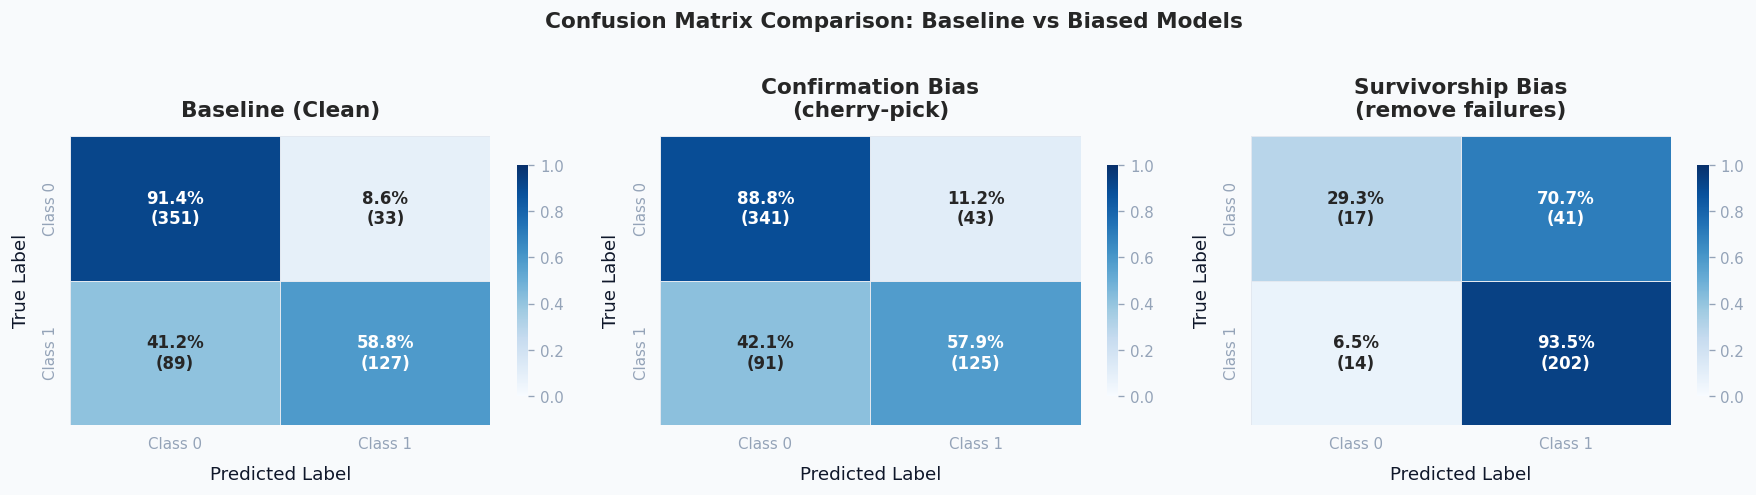

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    (report_cherry.baseline_cm,    'Baseline (Clean)',           axes[0]),
    (report_cherry.biased_cm,      'Confirmation Bias\n(cherry-pick)', axes[1]),
    (report_surv.biased_cm,        'Survivorship Bias\n(remove failures)', axes[2]),
]

for cm, title, ax in pairs:
    plot_confusion_matrix(cm, labels=['Class 0', 'Class 1'], title=title, ax=ax)

plt.suptitle('Confusion Matrix Comparison: Baseline vs Biased Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Confusion Matrix Comparison: Baseline vs Biased Models

Hình trên minh họa cách các loại **bias** khác nhau làm thay đổi cấu trúc lỗi trong **confusion matrix**. Điểm quan trọng là: bias không chỉ ảnh hưởng đến metric tổng, mà còn làm lệch **hành vi dự đoán** của model.

---

## 1. Baseline (Clean Data)

### Quan sát:

- TN: 91.4% (351)
- FP: 8.6% (33)
- FN: 41.2% (89)
- TP: 58.8% (127)

### Phân tích:

Model có xu hướng **thận trọng (conservative)**:

- FP thấp → ít dự đoán positive sai
- FN khá cao → bỏ sót nhiều positive

### Insight:

> Model ưu tiên **tránh false alarm** hơn là bắt hết positive.

Điều này phù hợp với các bài toán mà **FP cost cao**, nhưng có thể không phù hợp nếu mục tiêu là **max recall**.

---

## 2. Confirmation Bias (Feature Cherry-Picking)

### Quan sát:

- TN giảm: 91.4% → 88.8%
- FP tăng: 8.6% → 11.2%
- FN tăng nhẹ: 41.2% → 42.1%
- TP giảm nhẹ: 58.8% → 57.9%

### Phân tích:

- Cả FP và FN đều xấu đi
- Model bị lệch do chọn feature “ủng hộ giả thuyết ban đầu”

### Insight:

> Confirmation bias không làm model tốt hơn, mà làm **giảm chất lượng một cách âm thầm**.

- Metric tổng có thể gần như không đổi
- Nhưng error pattern đã xấu hơn

---

## 3. Survivorship Bias (Remove Failures)

### Quan sát:

- TN giảm mạnh: 91.4% → 29.3%
- FP tăng mạnh: 8.6% → 70.7%
- FN giảm mạnh: 41.2% → 6.5%
- TP tăng mạnh: 58.8% → 93.5%

### Phân tích:

Model gần như **predict positive cho hầu hết samples**:

- FN giảm mạnh → recall rất cao
- Nhưng FP tăng đột biến

### Insight:

> Model trở nên **lệch cực đoan về positive class**

- Trông có vẻ “tốt” nếu chỉ nhìn recall
- Nhưng thực tế sẽ gây **false alarm hàng loạt**

---

## 4. So sánh tổng quan

| Model              | FP        | FN        | Hành vi chính              |
|-------------------|----------|----------|----------------------------|
| Baseline          | Thấp     | Cao      | Conservative               |
| Confirmation Bias | Tăng nhẹ | Tăng nhẹ | Lệch nhẹ, kém ổn định      |
| Survivorship Bias | Rất cao  | Rất thấp | Over-predict positive      |

---

## 5. Key Insights

### Bias không luôn làm model “tốt hơn”

- Có thể làm model **tệ hơn toàn diện** (confirmation bias)
- Hoặc tạo ra **trade-off cực đoan** (survivorship bias)

---

### Metric tổng có thể gây hiểu lầm

Một số bias có thể:

- Làm tăng recall
- Hoặc giữ accuracy gần như không đổi

→ Nhưng **error distribution đã bị méo**

---

### Confusion Matrix là công cụ chẩn đoán quan trọng

> Metric cho bạn biết “model tốt đến đâu”
> Confusion matrix cho bạn biết “model sai như thế nào”

---

## 6. Kết luận

> Một model tốt không chỉ cần metric cao,
> mà cần **error pattern phù hợp với yêu cầu thực tế của bài toán**.

---
## 2. ROC Curve Comparison

### Khái niệm: ROC Curve

**ROC (Receiver Operating Characteristic) curve** mô tả mối quan hệ giữa:

- **TPR (True Positive Rate / Recall)**
- **FPR (False Positive Rate)**

khi thay đổi threshold từ 0 đến 1:

$$
\text{TPR} = \frac{TP}{TP + FN}, \quad
\text{FPR} = \frac{FP}{FP + TN}
$$

Mỗi điểm trên ROC curve tương ứng với một threshold khác nhau, phản ánh **trade-off giữa việc phát hiện positive và tránh false alarm**.

---

### AUC (Area Under the Curve)

**AUC** là diện tích dưới ROC curve:

$$
\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})
$$

Diễn giải xác suất:

$$
\text{AUC} = P(\hat{p}_{\text{positive}} > \hat{p}_{\text{negative}})
$$

Trong đó:

- $\hat{p}_{\text{positive}}$: score của một sample positive
- $\hat{p}_{\text{negative}}$: score của một sample negative

---

### Diễn giải AUC

- AUC = 0.5 → model hoạt động như random
- AUC = 1.0 → phân biệt hoàn hảo
- AUC càng cao → khả năng **xếp hạng (ranking)** giữa positive và negative càng tốt

---

### Ý nghĩa cốt lõi

ROC/AUC đo:

> **Khả năng phân biệt (discrimination), không phải quyết định phân loại cuối cùng**

- Không phụ thuộc vào threshold cụ thể
- Không bị ảnh hưởng trực tiếp bởi accuracy
- Phản ánh chất lượng của **score function**, không phải decision rule

---

### Liên hệ với Bias

ROC curve đặc biệt hữu ích trong phân tích bias vì:

> Nó tách biệt **model capability** khỏi **cách ta chọn threshold**

Nhờ đó, ta có thể phân biệt:

- Model thực sự học tốt
- Hay chỉ “trông tốt” do cách chọn threshold hoặc dữ liệu bị lệch

---

### Cơ chế bias ảnh hưởng đến ROC

#### 1. Dữ liệu bị “dễ hóa” (Data Simplification)

- Loại bỏ các samples khó (ví dụ: survivorship bias)
- Hai class trở nên dễ phân biệt hơn

→ Model học boundary rõ ràng hơn
→ **AUC tăng nhưng không phản ánh thực tế**

---

#### 2. Distribution Shift

- Train/test không cùng phân phối với dữ liệu thực tế
- ROC đo trên test set nhưng không đại diện cho production

→ AUC cao nhưng **generalization kém**

---

#### 3. Label Leakage / Feature Leakage

- Feature chứa thông tin trực tiếp hoặc gián tiếp về label
- Model học shortcut thay vì pattern thực

→ ROC curve gần như hoàn hảo (AUC ≈ 1)
→ Nhưng **không có giá trị thực tế**

---

### Hạn chế của ROC

Mặc dù mạnh, ROC có một số hạn chế quan trọng:

- Không phản ánh tác động của **class imbalance**
- Không thể hiện rõ chi phí của FP và FN
- Không cho biết performance tại một threshold cụ thể
- Có thể tạo cảm giác “lạc quan” trong một số bài toán skewed

---

### Key Insight

> ROC/AUC đánh giá khả năng **xếp hạng**, không đánh giá trực tiếp **chất lượng quyết định**.

Do đó:

- AUC cao chưa chắc model deploy tốt
- AUC thấp chưa chắc model vô dụng (có thể do data khó hoặc realistic hơn)

---

### Kết luận

ROC curve là công cụ quan trọng để:

- So sánh khả năng phân biệt giữa các model
- Phát hiện các dấu hiệu bất thường như bias hoặc leakage

Tuy nhiên, để đánh giá đầy đủ, cần kết hợp với:

- Confusion matrix (phân tích lỗi cụ thể)
- Threshold-based metrics (precision, recall, F1)
- Phân tích distribution của dữ liệu

> Một model có AUC cao vẫn có thể thất bại nếu dữ liệu hoặc quy trình đánh giá bị bias.

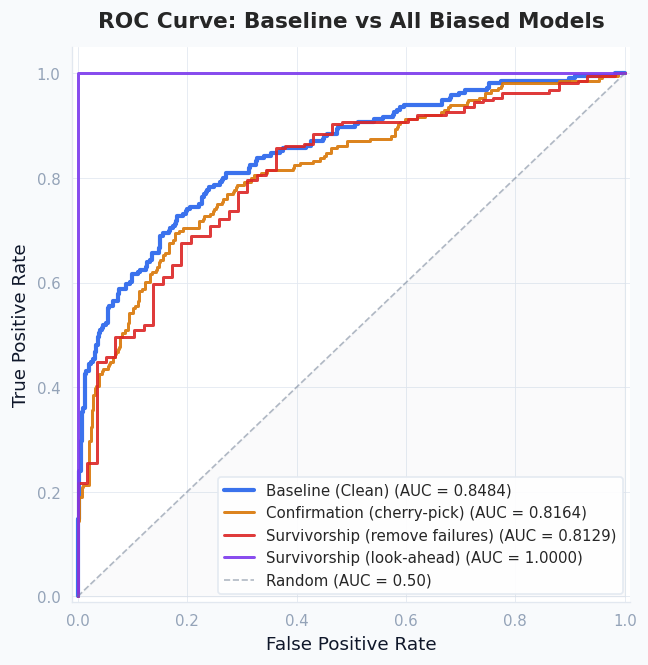

In [4]:
y_true_dict, y_proba_dict = {}, {}

model_map = {
    'Baseline (Clean)':              baseline,
    'Confirmation (cherry-pick)':    model_cherry,
    'Survivorship (remove failures)': model_surv,
    'Survivorship (look-ahead)':     model_lookahead,
}

for label, model in model_map.items():
    if model.y_proba is not None:
        y_true_dict[label]  = model.y_true
        y_proba_dict[label] = model.y_proba

from src.visualization.plots import PALETTE
colors = {
    'Baseline (Clean)':               PALETTE['baseline'],
    'Confirmation (cherry-pick)':     PALETTE['warning'],
    'Survivorship (remove failures)': PALETTE['biased'],
    'Survivorship (look-ahead)':      '#7C3AED',
}

fig, _ = plot_roc_curve(
    y_true_dict, y_proba_dict,
    colors=colors,
    title='ROC Curve: Baseline vs All Biased Models',
)
plt.show()

## ROC Curve Comparison: Baseline vs Biased Models

Biểu đồ ROC trên so sánh khả năng **phân biệt (discrimination)** của các model dưới các dạng bias khác nhau. Điểm quan trọng là: không phải mọi bias đều làm AUC tăng — một số làm giảm, một số làm tăng giả tạo.

---

## 1. Baseline (Clean Data)

- AUC = **0.8484**

### Insight:

- Đây là mức performance đáng tin cậy
- ROC curve nằm ổn định phía trên đường chéo
- Phản ánh đúng khả năng phân biệt của model trên dữ liệu không bias

Đây là mốc chuẩn để so sánh các model khác.

---

## 2. Confirmation Bias (Cherry-Pick Features)

- AUC = **0.8164** (giảm)

### Phân tích:

- ROC curve nằm dưới baseline gần như toàn bộ range
- Khả năng phân biệt bị suy giảm

### Insight:

Feature selection bị bias đã làm mất thông tin quan trọng.
Model học theo giả định chủ quan thay vì dữ liệu thực tế.

---

## 3. Survivorship Bias (Remove Failures)

- AUC = **0.8129** (giảm)

### Phân tích:

- ROC curve tiếp tục thấp hơn baseline
- Dữ liệu bị thay đổi distribution

### Insight:

Loại bỏ failure không làm model tốt hơn, mà làm nó hiểu sai dữ liệu.
Khi áp dụng vào dữ liệu thực, performance giảm.

---

## 4. Survivorship Bias (Look-Ahead / Leakage)

- AUC = **1.0000**

### Phân tích:

- ROC curve chạm góc trên bên trái
- Model phân biệt hoàn hảo

### Insight:

Đây là dấu hiệu rõ ràng của data leakage:

- Model có thông tin liên quan trực tiếp đến label
- Không phải là khả năng học thực sự

---

## 5. So sánh tổng quan

| Model                          | AUC     | Đánh giá                |
|--------------------------------|--------|-------------------------|
| Baseline (clean)              | 0.8484 | Đáng tin cậy           |
| Confirmation bias             | 0.8164 | Giảm chất lượng        |
| Survivorship (remove failures)| 0.8129 | Sai lệch distribution  |
| Survivorship (look-ahead)     | 1.0000 | Có dấu hiệu leakage    |

---

## 6. Key Insights

### Bias không luôn làm AUC tăng

- Một số bias làm model kém đi (confirmation bias)
- Một số làm dữ liệu không còn đại diện (survivorship bias)

---

### AUC quá cao là dấu hiệu bất thường

Trong thực tế, AUC gần 1.0 hiếm khi xảy ra.
Giá trị này thường liên quan đến:

- Data leakage
- Feature chứa thông tin về label
- Sai sót trong pipeline

---

### ROC chỉ phản ánh khả năng phân biệt

ROC/AUC đo khả năng sắp xếp (ranking), không phản ánh trực tiếp:

- tỉ lệ lỗi cụ thể
- chi phí của FP và FN

Do đó cần kết hợp với confusion matrix.

---

## 7. Kết luận

ROC/AUC là công cụ quan trọng để đánh giá model, nhưng không nên sử dụng một cách độc lập.

Để đánh giá đúng, cần:

- So sánh với baseline
- Phân tích thêm confusion matrix
- Kiểm tra các dấu hiệu bias hoặc leakage

Một model tốt không chỉ có AUC cao, mà còn phải phản ánh đúng hành vi trên dữ liệu thực tế.

---
## 3. Calibration Analysis

### Khái niệm: Reliability Diagram

**Reliability diagram** (calibration plot) dùng để đánh giá mức độ **calibration** của model, tức là:

> Xác suất dự đoán có phản ánh đúng xác suất xảy ra trong thực tế hay không.

Cách xây dựng:

- Chia predicted probabilities thành các **bins** (ví dụ: [0–0.1], [0.1–0.2], …)
- Với mỗi bin:
  - Trục X: **mean predicted probability** $\text{conf}(B_m)$
  - Trục Y: **actual fraction of positives** $\text{acc}(B_m)$

---

### Diễn giải

- Model **perfectly calibrated**:
  $$
  y = x
  $$
  → xác suất dự đoán khớp với tần suất thực tế

---

### Overconfident vs Underconfident

#### Overconfident model

- Nằm **dưới đường chéo**
- Dự đoán xác suất cao hơn thực tế:

$$
\text{conf}(B_m) > \text{acc}(B_m)
$$

Ví dụ: model dự đoán 0.9 nhưng thực tế chỉ đúng ~0.7

---

#### Underconfident model

- Nằm **trên đường chéo**
- Dự đoán xác suất thấp hơn thực tế:

$$
\text{conf}(B_m) < \text{acc}(B_m)
$$

---

### Ý nghĩa của Calibration

Khác với ROC/AUC:

- ROC đo **khả năng phân biệt (ranking)**
- Calibration đo **độ tin cậy của xác suất**

Một model có thể:

- AUC cao nhưng **calibration kém**
- Phân biệt đúng thứ tự, nhưng xác suất sai lệch

---

### Overconfidence Index (OCI)

Để lượng hóa mức độ lệch calibration trung bình, ta dùng:

$$
\text{OCI} = \bar{\hat{p}} - \bar{y}
$$

Trong đó:

- $\bar{\hat{p}}$: mean predicted probability
- $\bar{y}$: actual positive rate

---

### Diễn giải OCI

- $\text{OCI} > 0$ → model **overconfident**
- $\text{OCI} = 0$ → calibrated trung bình
- $\text{OCI} < 0$ → model **underconfident**

---

### Hạn chế của OCI

OCI chỉ phản ánh **bias trung bình**, không phản ánh:

- local miscalibration theo từng bin
- hình dạng của calibration curve

Một model có thể:

- OCI ≈ 0
- nhưng vẫn **mất calibration nghiêm trọng ở từng vùng**

---

### Nguyên nhân gây miscalibration

Một số nguyên nhân phổ biến:

- Overfitting (model quá tự tin vào training data)
- Data bias hoặc distribution shift
- Loss function không tối ưu calibration (ví dụ: log-loss vs hinge loss)
- Class imbalance

---

### Liên hệ với Bias

Bias thường dẫn đến **overconfidence**, đặc biệt khi:

- Train trên dữ liệu “dễ” hơn thực tế
- Có leakage hoặc shortcut feature

→ Model dự đoán xác suất cao nhưng không phản ánh đúng xác suất thật

---

### Key Insight

> Một model tốt không chỉ cần phân biệt đúng, mà còn cần **ước lượng xác suất đúng**.

---

### Kết luận

- Reliability diagram giúp đánh giá calibration trực quan
- OCI cung cấp một chỉ số tóm tắt nhanh

Tuy nhiên, để đánh giá đầy đủ cần:

- Xem toàn bộ calibration curve
- Kết hợp với ROC/AUC và confusion matrix

> Model có AUC cao nhưng calibration kém vẫn có thể gây ra quyết định sai trong thực tế

In [5]:
# So sanh calibration: baseline vs probability-inflated
orig_cal   = compute_calibration_metrics(oc_inflate.y_true, oc_inflate.y_proba_original)
biased_cal = compute_calibration_metrics(oc_inflate.y_true, oc_inflate.y_proba_biased)

print('Calibration comparison:')
print(f'  Baseline ECE  : {orig_cal.get("ece", 0):.4f}')
print(f'  Inflated ECE  : {biased_cal.get("ece", 0):.4f}')
print(f'  Baseline OCI  : {orig_cal.get("overconfidence_index", 0):+.4f}')
print(f'  Inflated OCI  : {biased_cal.get("overconfidence_index", 0):+.4f}')
print(f'  Baseline Brier: {orig_cal.get("brier_score", 0):.4f}')
print(f'  Inflated Brier: {biased_cal.get("brier_score", 0):.4f}')

Calibration comparison:
  Baseline ECE  : 0.0398
  Inflated ECE  : 0.0701
  Baseline OCI  : -0.0005
  Inflated OCI  : -0.0446
  Baseline Brier: 0.1442
  Inflated Brier: 0.1480


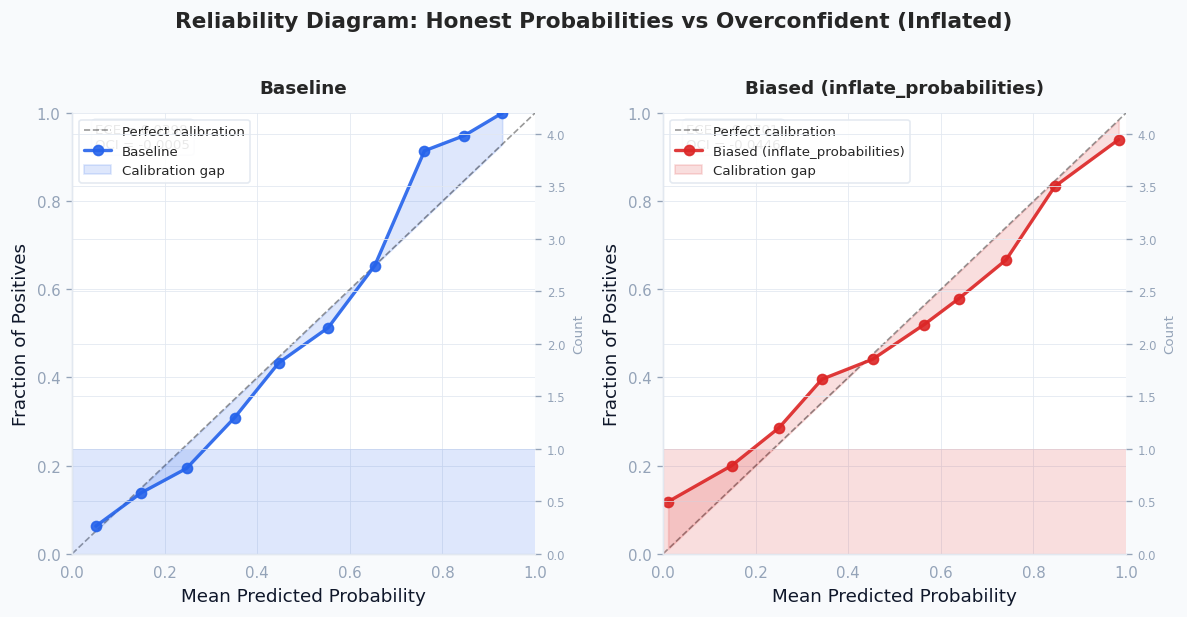

In [6]:
fake_report_cal = ComparisonReport(
    bias_type='overconfidence_bias',
    bias_strategy='inflate_probabilities',
    baseline_calibration=orig_cal,
    biased_calibration=biased_cal,
)

fig, _ = plot_calibration_comparison(
    fake_report_cal,
    title='Reliability Diagram: Honest Probabilities vs Overconfident (Inflated)',
)
plt.show()

## Calibration Analysis: Baseline vs Overconfident Model

Biểu đồ reliability diagram trên so sánh mức độ **calibration** giữa:

- Model baseline (xác suất “honest”)
- Model bị bias (inflate probabilities)

Mục tiêu là kiểm tra: **xác suất dự đoán có phản ánh đúng thực tế hay không**.

---

## 1. Baseline Model

### Quan sát:

- Các điểm nằm gần đường chéo $y = x$
- Sai lệch nhỏ, phân bố tương đối đều

### Insight:

- Model **được calibration tốt**
- Xác suất dự đoán phản ánh khá chính xác tần suất thực tế

---

## 2. Biased Model (Inflated Probabilities)

### Quan sát:

- Đường cong lệch khỏi đường chéo rõ rệt
- Sai lệch tăng ở nhiều vùng xác suất

### Insight:

- Model bị **miscalibrated**
- Xác suất dự đoán không còn phản ánh đúng thực tế

---

## 3. Calibration Metrics Comparison

| Metric        | Baseline | Inflated | Nhận xét |
|--------------|----------|----------|----------|
| ECE          | 0.0398   | 0.0701   | Sai lệch tăng đáng kể |
| OCI          | -0.0005  | -0.0446  | Chuyển sang xu hướng underconfident |
| Brier Score  | 0.1442   | 0.1480   | Xác suất tổng thể kém hơn |

---

### Phân tích chi tiết

#### Expected Calibration Error (ECE)

- Baseline: 0.0398
- Inflated: 0.0701

> ECE tăng gần gấp đôi → calibration xấu đi rõ rệt

ECE đo độ lệch trung bình giữa predicted probability và actual frequency.

---

#### Overconfidence Index (OCI)

- Baseline: -0.0005 ≈ 0
- Inflated: -0.0446

> Model chuyển sang **underconfident trên trung bình**

Lưu ý:

- OCI là metric **global**
- Có thể trái ngược với local pattern trên curve

---

#### Brier Score

- Baseline: 0.1442
- Inflated: 0.1480

> Brier score tăng → chất lượng dự đoán xác suất giảm

Brier score đo cả:

- Calibration
- Và discrimination

---

## 4. Insight quan trọng

### Calibration không phải một con số duy nhất

- Reliability diagram → cho thấy **local behavior**
- ECE → đo sai lệch trung bình
- OCI → đo bias toàn cục
- Brier → đánh giá tổng thể xác suất

→ Cần kết hợp nhiều metric để hiểu đầy đủ

---

### Bias có thể làm méo calibration theo nhiều cách

- Có thể overconfident ở một số vùng
- Nhưng underconfident ở vùng khác
- OCI có thể gần 0 nhưng vẫn miscalibrated

---

## 5. Kết luận

- Baseline model:
  - Calibration tốt (ECE thấp, OCI ≈ 0)
  - Xác suất đáng tin cậy

- Inflated model:
  - Calibration kém hơn (ECE tăng, Brier xấu hơn)
  - Xác suất không còn phản ánh đúng thực tế

> Một model tốt không chỉ cần phân biệt đúng (AUC),
> mà còn phải **dự đoán xác suất chính xác (calibrated probabilities)**.

---
## 4. Severity Heatmap

### Khái niệm: Heatmap

**Heatmap** là một dạng visualization biểu diễn giá trị số bằng màu sắc trên một ma trận 2 chiều.

Trong bối cảnh **bias analysis**:

- **Rows**: các bias strategies
- **Columns**: các evaluation metrics (AUC, Accuracy, F1, ECE, …)
- **Cell value**: độ thay đổi tương đối (|relative change %|)
- **Color intensity**: mức độ tác động (càng đậm → ảnh hưởng càng lớn)

---

### Vai trò của Heatmap

Heatmap cho phép:

- So sánh **nhiều bias trên nhiều metrics cùng lúc**
- Nhận diện nhanh:
  - Bias nào gây ảnh hưởng mạnh nhất
  - Metric nào nhạy cảm với bias nào

> Đây là công cụ tổng hợp hiệu quả hơn so với việc xem từng biểu đồ riêng lẻ.

---

### Khái niệm: Relative Change

**Relative change** chuẩn hóa mức thay đổi của metric so với baseline:

$$
\text{Relative Change (\%)} =
\frac{\text{metric}_{\text{biased}} - \text{metric}_{\text{baseline}}}
{\text{metric}_{\text{baseline}}}
\times 100
$$

---

### Ý nghĩa

Relative change giúp:

- So sánh công bằng giữa các metrics có **scale khác nhau**
- Đánh giá mức độ “inflate” hoặc “degrade” một cách nhất quán

Ví dụ:

- Accuracy: 0.80 → 0.84  → +5%
- AUC: 0.90 → 0.945 → +5%

→ Cả hai được xem là **cùng mức độ thay đổi**, dù absolute delta khác nhau

---

### Tại sao dùng giá trị tuyệt đối?

Trong heatmap, thường dùng:

$$
|\text{Relative Change}|
$$

để:

- Tập trung vào **mức độ ảnh hưởng**, không phải hướng tăng/giảm
- Dễ so sánh mức độ “severity” giữa các bias

Tuy nhiên, khi phân tích chi tiết, cần xem thêm **dấu (+/−)** để biết:

- Metric bị inflate (tăng)
- Hay degrade (giảm)

---

### Insight quan trọng

> Không phải mọi bias đều ảnh hưởng giống nhau trên mọi metric.

- Một số bias:
  - Tăng mạnh AUC nhưng ít ảnh hưởng F1
- Một số khác:
  - Làm calibration (ECE, Brier) xấu đi nhưng AUC gần như giữ nguyên

---

### Lợi ích trong thực tế

Severity heatmap giúp:

- Phát hiện **bias nguy hiểm nhất** trong pipeline
- Xác định metric nào đang bị “đánh lừa”
- Hỗ trợ decision:
  - Có nên trust model hay không
  - Bias nào cần xử lý trước

---

### Kết luận

Heatmap là công cụ tổng hợp giúp chuyển từ:

- Phân tích từng metric riêng lẻ

sang:

- Nhìn toàn bộ hệ thống một cách **đa chiều**

> Một bias nguy hiểm không phải là bias làm thay đổi một metric,
> mà là bias làm thay đổi **nhiều metric theo cách nhất quán và khó phát hiện**

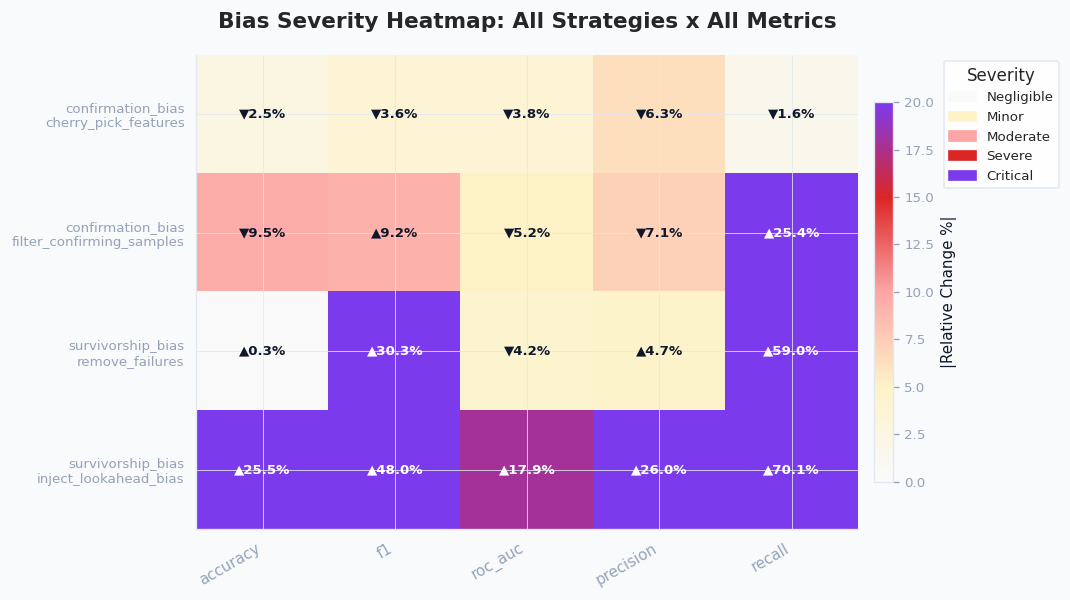

In [7]:
fig, _ = plot_severity_heatmap(
    all_reports,
    metrics=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    title='Bias Severity Heatmap: All Strategies x All Metrics',
)
plt.show()

## Severity Heatmap: Bias Impact Across Metrics

Heatmap trên tổng hợp mức độ ảnh hưởng của các bias lên nhiều metrics thông qua **relative change (%)**. Mỗi ô thể hiện độ thay đổi so với baseline, giúp nhận diện nhanh bias nào nguy hiểm và ảnh hưởng theo hướng nào.

---

## 1. Tổng quan

- Màu nhạt → ảnh hưởng nhỏ
- Màu đậm → ảnh hưởng lớn
- Giá trị hiển thị trong mỗi ô → **% thay đổi tương đối**

Các metrics gồm:

- Accuracy
- F1-score
- ROC-AUC
- Precision
- Recall

---

## 2. Confirmation Bias (Cherry-Pick Features)

### Quan sát:

- Accuracy: ▼2.5%
- F1: ▼3.6%
- AUC: ▼3.8%
- Precision: ▼6.3%
- Recall: ▼1.6%

### Insight:

- Ảnh hưởng **nhỏ nhưng đồng đều theo hướng tiêu cực**
- Model suy giảm nhẹ trên tất cả metrics

> Đây là dạng bias làm model kém đi một cách “âm thầm”

---

## 3. Confirmation Bias (Filter Confirming Samples)

### Quan sát:

- Accuracy: ▼9.5%
- F1: ▲9.2%
- AUC: ▼5.2%
- Precision: ▼7.1%
- Recall: ▲25.4%

### Insight:

- Recall tăng mạnh (+25.4%)
- Nhưng accuracy và AUC giảm

> Bias này làm model **thiên về predict positive**

- Bắt được nhiều positive hơn
- Nhưng overall performance giảm

---

## 4. Survivorship Bias (Remove Failures)

### Quan sát:

- Accuracy: ▲0.3% (gần như không đổi)
- F1: ▲30.3%
- AUC: ▼4.2%
- Precision: ▲4.7%
- Recall: ▲59.0%

### Insight:

- Recall tăng cực mạnh (+59%)
- F1 tăng lớn
- Nhưng AUC lại giảm

> Model trông rất tốt nếu chỉ nhìn F1/Recall
> nhưng thực chất **khả năng phân biệt kém đi**

---

## 5. Survivorship Bias (Look-Ahead / Leakage)

### Quan sát:

- Accuracy: ▲25.5%
- F1: ▲48.0%
- AUC: ▲17.9%
- Precision: ▲26.0%
- Recall: ▲70.1%

### Insight:

- Tất cả metrics đều tăng mạnh
- Đây là dấu hiệu điển hình của **data leakage**

> Model “tốt toàn diện” một cách bất thường

---

## 6. So sánh mức độ nguy hiểm

| Bias Type                         | Pattern chính                      | Mức độ |
|----------------------------------|-----------------------------------|--------|
| Cherry-pick features             | Giảm nhẹ toàn bộ                  | Thấp   |
| Filter confirming samples        | Trade-off lệch (recall ↑)         | Trung  |
| Remove failures                  | Inflate recall/F1                 | Cao    |
| Look-ahead (leakage)             | Inflate toàn bộ metrics           | Rất cao|

---

## 7. Key Insights

### Không phải metric nào cũng phản ánh đúng

- Recall và F1 dễ bị inflate mạnh
- AUC ổn định hơn nhưng vẫn có thể bị ảnh hưởng

---

### Bias tạo ra các “pattern” khác nhau

- Confirmation bias → degrade nhẹ
- Survivorship bias → lệch về positive
- Leakage → inflate toàn diện

---

### Heatmap giúp nhìn multi-dimensional

> Một bias nguy hiểm không phải là bias làm tăng một metric,
> mà là bias tạo ra **pattern bất thường trên nhiều metrics**

---

## 8. Kết luận

- Heatmap cung cấp cái nhìn tổng quan về tác động của bias
- Giúp phát hiện:
  - Metric nào bị “đánh lừa”
  - Bias nào cần ưu tiên xử lý

> Đánh giá model cần nhìn **toàn bộ hệ metrics**, không chỉ một con số đơn lẻ

---
## 5. Before / After Impact Charts

### Khái niệm: Before/After Visualization

**Before/after chart** (grouped bar chart) dùng để so sánh trực tiếp **baseline** và **biased model** trên cùng một tập metrics.

- Mỗi metric có hai cột:
  - Baseline (trước khi có bias)
  - Biased (sau khi bị tác động)

---

### Cách đọc biểu đồ

Khi phân tích before/after chart, cần chú ý:

- **Chiều cao của bar**
  → giá trị tuyệt đối của metric

- **Delta annotation (±x.x)**
  → mức thay đổi tuyệt đối so với baseline

- **Severity badge**
  → phân loại mức độ ảnh hưởng (nhỏ, trung bình, nghiêm trọng)

---

### Ý nghĩa của sự thay đổi

- Bar biased **cao hơn** baseline
  → metric bị **inflate**

- Bar biased **thấp hơn** baseline
  → metric bị **degrade**

Tuy nhiên:

> Sự thay đổi của metric không trực tiếp phản ánh chất lượng model.

---

### Insight quan trọng

#### 1. Metric tăng không đồng nghĩa model tốt hơn

- Bias có thể làm metric tăng một cách giả tạo
- Đặc biệt với:
  - Recall
  - F1-score
  - Accuracy (trong một số trường hợp)

→ Model trông tốt hơn nhưng **không generalize**

---

#### 2. Cần nhìn nhiều metrics cùng lúc

Một model có thể:

- Recall tăng
- Nhưng precision giảm
- Hoặc AUC giảm

→ Nếu chỉ nhìn một metric, dễ bị đánh lừa

---

#### 3. Absolute delta chưa đủ

- Delta lớn không luôn nguy hiểm
- Quan trọng là:
  - Metric nào bị ảnh hưởng
  - Pattern thay đổi có hợp lý không

---

### Liên hệ với Bias

Before/after chart giúp trả lời:

- Bias đang làm metric nào thay đổi mạnh nhất
- Sự thay đổi có nhất quán không
- Có dấu hiệu bất thường (inflate toàn diện) hay không

---

### Ví dụ pattern điển hình

- Confirmation bias
  → giảm nhẹ nhiều metrics

- Survivorship bias
  → tăng mạnh recall, F1

- Data leakage
  → tăng mạnh tất cả metrics

---

### Hạn chế

- Không thể hiện distribution hoặc uncertainty
- Không cho thấy mối quan hệ giữa các metrics
- Có thể gây hiểu lầm nếu không xem cùng các biểu đồ khác

---

### Kết luận

Before/after chart là công cụ trực quan để:

- So sánh nhanh tác động của bias
- Nhận diện metric bị thay đổi

Tuy nhiên:

> Cần kết hợp với ROC, confusion matrix và calibration
> để hiểu đầy đủ bản chất của sự thay đổi.

Một model có metric cao hơn sau khi bị bias không phải là model tốt hơn,
mà chỉ là model được đánh giá trên một điều kiện không còn trung thực.

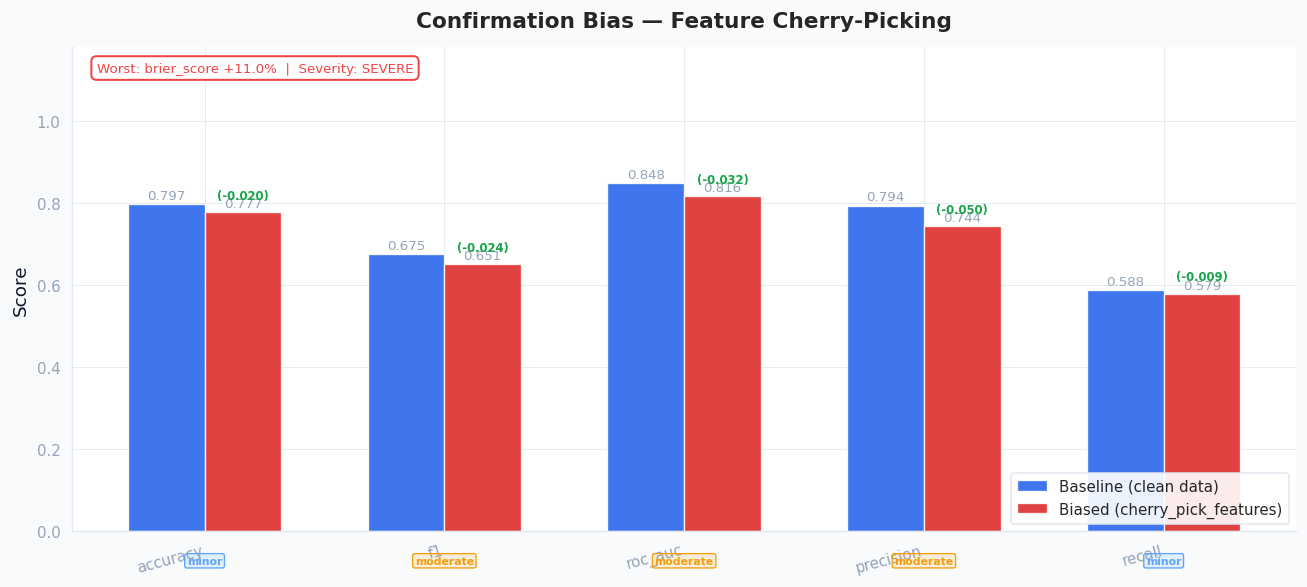

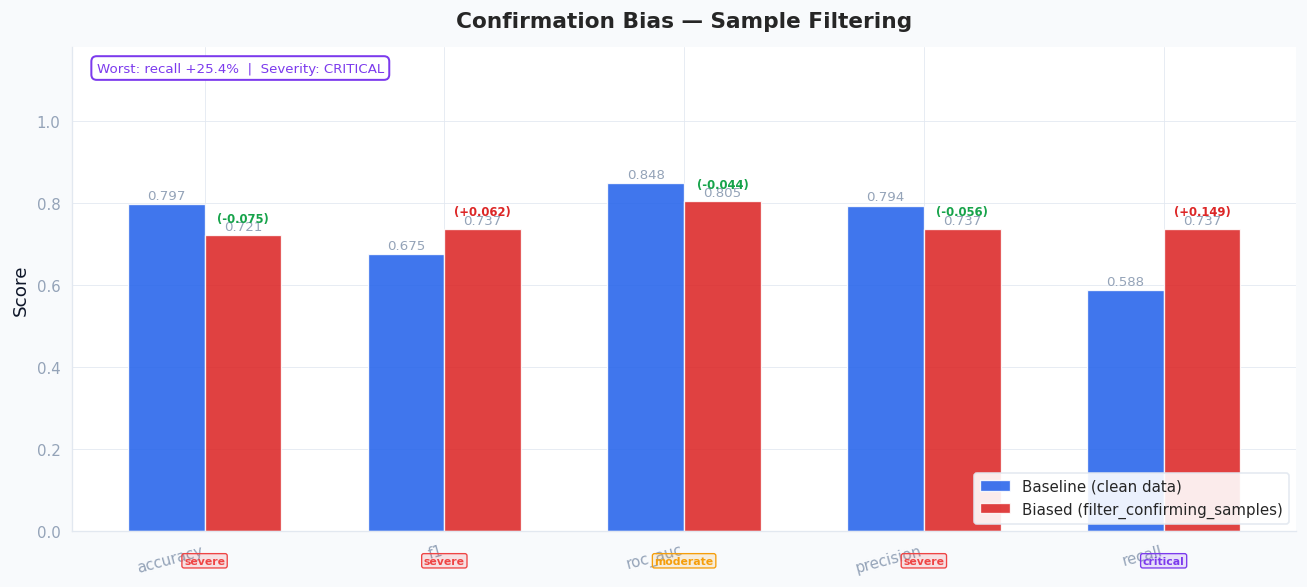

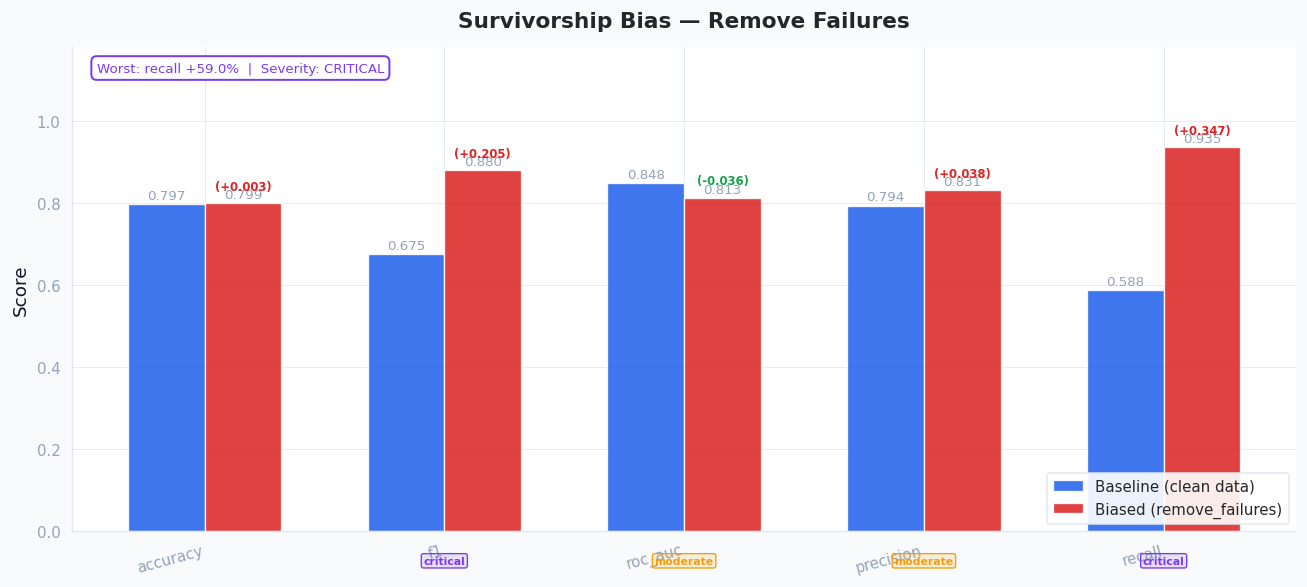

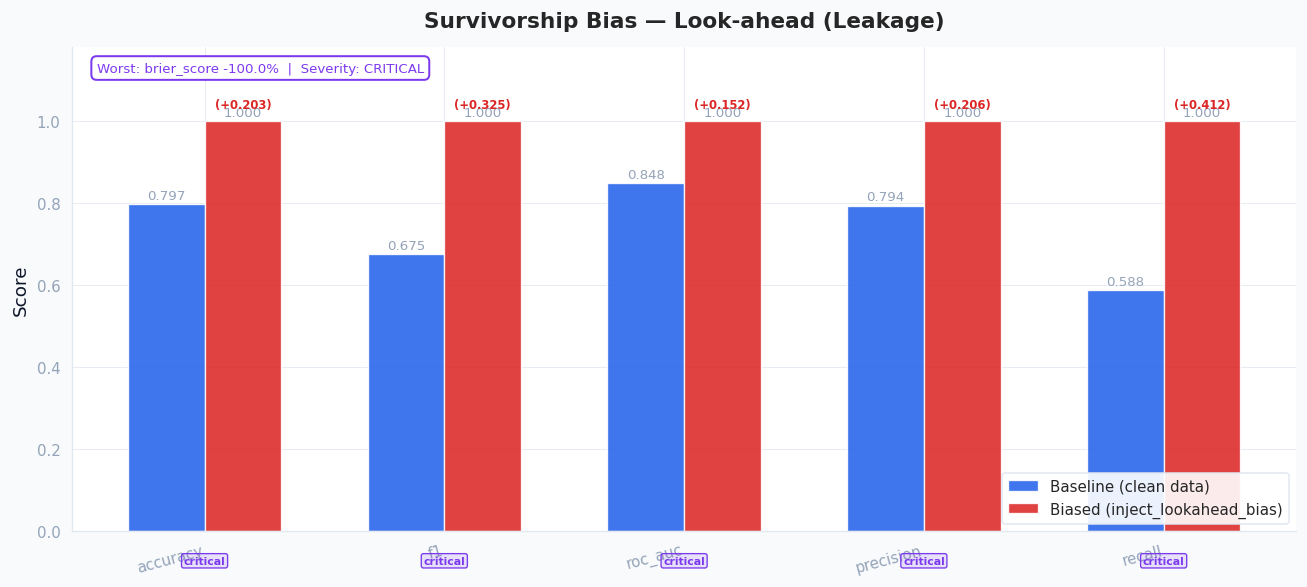

In [8]:
report_titles = [
    (report_cherry,    'Confirmation Bias — Feature Cherry-Picking'),
    (report_filter,    'Confirmation Bias — Sample Filtering'),
    (report_surv,      'Survivorship Bias — Remove Failures'),
    (report_lookahead, 'Survivorship Bias — Look-ahead (Leakage)'),
]

for report, title in report_titles:
    fig, _ = plot_bias_impact_bars(report, title=title)
    plt.show()

## Before / After Impact Analysis

Các biểu đồ trên so sánh trực tiếp giữa **baseline** và các model bị bias trên từng metric. Việc phân tích cần tập trung vào **pattern thay đổi**, không chỉ giá trị tăng/giảm.

---

## 1. Confirmation Bias — Feature Cherry-Picking

### Quan sát:

- Tất cả metrics đều **giảm nhẹ**:
  - Accuracy: -0.020
  - F1: -0.024
  - AUC: -0.032
  - Precision: -0.050
  - Recall: -0.009

- Worst: **Brier score +11% (SEVERE)**

### Insight:

- Model bị suy giảm **đồng đều trên mọi khía cạnh**
- Không có metric nào được cải thiện

> Đây là dạng bias làm model kém đi một cách “ổn định và khó nhận ra”

---

## 2. Confirmation Bias — Sample Filtering

### Quan sát:

- Recall tăng mạnh: **+0.149 (~+25%)**
- F1 tăng: +0.062
- Nhưng:
  - Accuracy: -0.075
  - AUC: -0.044
  - Precision: -0.056

### Insight:

- Model bị **lệch về positive prediction**
- Trade-off rõ ràng:
  - Recall ↑ mạnh
  - Precision & AUC ↓

> Nếu chỉ nhìn recall/F1 → model trông tốt hơn
> Nhưng thực tế **overall performance giảm**

---

## 3. Survivorship Bias — Remove Failures

### Quan sát:

- Recall tăng cực mạnh: **+0.347 (~+59%)**
- F1 tăng mạnh: +0.205
- Precision tăng nhẹ: +0.038
- Nhưng:
  - AUC giảm: -0.036
  - Accuracy gần như không đổi

### Insight:

- Model gần như “predict positive nhiều hơn”
- Performance bị **inflate theo hướng recall**

> Đây là dạng bias nguy hiểm:
- Metric phổ biến (F1, recall) tăng mạnh
- Nhưng discrimination (AUC) lại giảm

---

## 4. Survivorship Bias — Look-ahead (Leakage)

### Quan sát:

- Tất cả metrics đều tăng mạnh:
  - Accuracy: +0.203
  - F1: +0.325
  - AUC: +0.152
  - Precision: +0.206
  - Recall: +0.412

- Tất cả đều ở mức **CRITICAL**

### Insight:

- Model “tốt toàn diện” một cách bất thường

> Đây là dấu hiệu điển hình của **data leakage**

- Model có thông tin về label
- Không còn là learning thực sự

---

## 5. So sánh pattern

| Bias Type                | Pattern chính                          |
|-------------------------|----------------------------------------|
| Cherry-pick features    | Giảm nhẹ toàn bộ metrics               |
| Sample filtering        | Recall ↑, các metric khác ↓            |
| Remove failures         | Recall & F1 ↑ mạnh, AUC ↓              |
| Look-ahead (leakage)    | Tất cả metrics ↑ mạnh                  |

---

## 6. Key Insights

### Metric tăng không đồng nghĩa model tốt hơn

- Recall/F1 rất dễ bị inflate
- AUC là metric ổn định hơn nhưng vẫn có thể bị ảnh hưởng

---

### Pattern quan trọng hơn giá trị

- Bias không chỉ làm metric thay đổi
- Mà tạo ra **dấu vết đặc trưng (signature)** trên các metrics

---

### Leakage là trường hợp đặc biệt

- Khi mọi metric đều tăng mạnh
→ gần như chắc chắn có vấn đề trong pipeline

---

## 7. Kết luận

Before/after charts giúp:

- Nhìn rõ tác động của bias trên từng metric
- Phát hiện các pattern bất thường

> Đánh giá model cần dựa trên **toàn bộ hệ metrics**,
> không dựa vào một chỉ số riêng lẻ

---
## 6. Survivorship Funnel

### Khái niệm: Funnel Chart

**Funnel chart** là dạng biểu đồ thể hiện quá trình **lọc dữ liệu qua nhiều bước**, trong đó:

- Mỗi stage tương ứng với một bước filtering
- Số lượng samples **giảm dần theo từng bước**
- Hình dạng tổng thể giống một **phễu (funnel)**

---

### Ứng dụng trong Survivorship Bias

Trong phân tích **survivorship bias**, funnel chart giúp trả lời các câu hỏi quan trọng:

- Bao nhiêu samples bị loại bỏ ở mỗi bước?
- Tỉ lệ **failures** trong số bị loại là bao nhiêu?
- **Class distribution** thay đổi như thế nào sau mỗi lần filter?

---

### Ý nghĩa trực quan

Funnel chart cho thấy:

- Không chỉ số lượng data giảm
- Mà còn cho thấy **data bị loại theo hướng nào**

Ví dụ:

- Nếu phần lớn samples bị loại là **negative class**
→ dataset trở nên **mất cân bằng**

- Nếu giữ lại chủ yếu “successful cases”
→ model sẽ học một **phiên bản không đầy đủ của thực tế**

---

### Liên hệ với Bias

> Survivorship bias xảy ra khi pipeline chỉ giữ lại “những gì còn lại” sau filtering, và bỏ qua những trường hợp thất bại.

Hệ quả:

- Model không học được đầy đủ distribution
- Boundary bị lệch
- Dễ dẫn đến:
  - Recall cao giả tạo
  - FP tăng mạnh khi deploy

---

### Tại sao Funnel Chart hiệu quả?

So với các biểu đồ khác:

- Confusion matrix → thể hiện lỗi
- ROC → thể hiện khả năng phân biệt
- Heatmap → tổng hợp multi-metric

Funnel chart:

> Trực tiếp cho thấy **nguồn gốc của bias từ data pipeline**

---

### Lợi ích trong communication

Funnel chart đặc biệt hữu ích khi làm việc với stakeholders:

- Dễ hiểu, không cần kiến thức ML sâu
- Trực quan về việc “data bị mất đi như thế nào”
- Giúp giải thích:
  - Vì sao model trông tốt
  - Nhưng lại fail trong thực tế

---

### Key Insight

> Bias không chỉ đến từ model, mà bắt đầu từ **cách dữ liệu bị lọc và chọn**.

---

### Kết luận

- Funnel chart là công cụ quan trọng để phân tích survivorship bias
- Giúp kết nối:
  - Data preprocessing
  - Model behavior
  - Evaluation metrics

> Một model bị bias thường bắt đầu từ một funnel “lệch”,
> nơi dữ liệu bị loại bỏ không ngẫu nhiên.

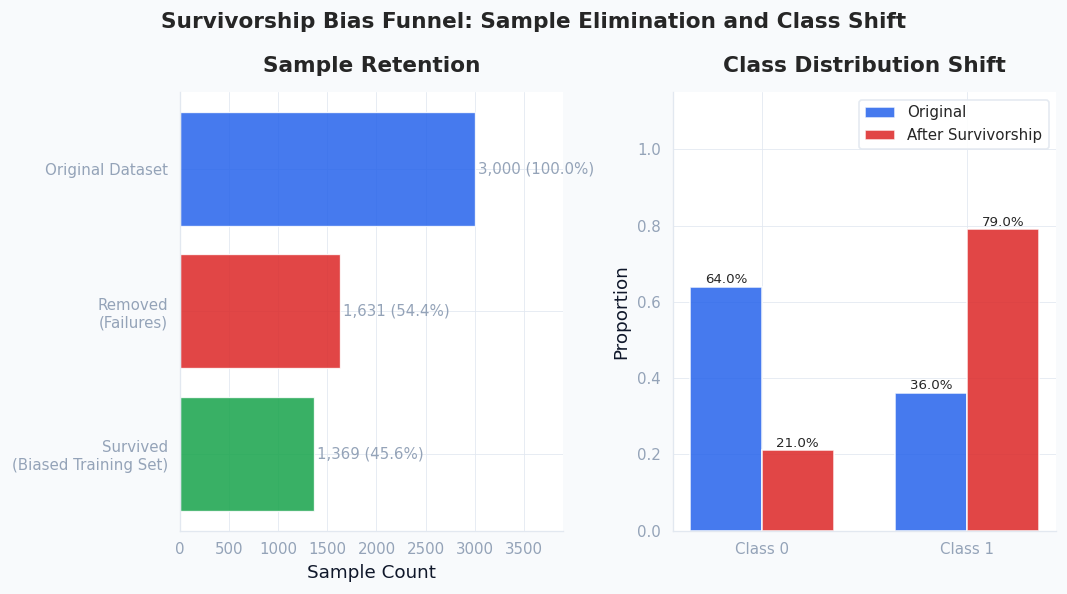

In [9]:
fig, _ = plot_survivorship_funnel(
    b_surv.bias_report,
    title='Survivorship Bias Funnel: Sample Elimination and Class Shift',
)
plt.show()

## Survivorship Funnel: Sample Elimination and Class Shift

Biểu đồ funnel trên minh họa rõ cách **survivorship bias được tạo ra từ data pipeline**, thông qua hai khía cạnh:

- Sample retention (bao nhiêu dữ liệu bị loại)
- Class distribution shift (phân phối class thay đổi như thế nào)

---

## 1. Sample Retention

### Quan sát:

- Original dataset: **3,000 samples (100%)**
- Removed (failures): **1,631 samples (54.4%)**
- Survived: **1,369 samples (45.6%)**

### Insight:

- Hơn **một nửa dữ liệu bị loại bỏ**
- Việc loại bỏ không ngẫu nhiên mà tập trung vào **failures**

> Dataset sau filtering không còn đại diện cho thực tế

---

## 2. Class Distribution Shift

### Quan sát:

| Class | Original | After Survivorship |
|-------|----------|-------------------|
| Class 0 | 64.0% | 21.0% |
| Class 1 | 36.0% | 79.0% |

### Insight:

- Class distribution bị đảo chiều mạnh
- Class 1 (positive) trở thành majority

> Model sẽ học rằng “positive là phổ biến”, dù thực tế không phải vậy

---

## 3. Cơ chế tạo bias

Quá trình filtering:

1. Loại bỏ failures
2. Failures chủ yếu thuộc Class 0
3. Dataset còn lại bị skew về Class 1

→ Model học trên một **distribution bị lệch**

---

## 4. Hệ quả lên model

### Trong training:

- Model thấy nhiều positive hơn
- Decision boundary dịch về phía positive

---

### Trong evaluation (biased data):

- Recall tăng mạnh
- F1 có thể tăng
- Model trông “tốt hơn”

---

### Trong deployment (real data):

- FP tăng mạnh
- Model predict positive quá mức
- Performance thực tế giảm

---

## 5. Insight quan trọng

> Bias không xuất hiện ở model, mà xuất hiện từ **cách dữ liệu bị loại bỏ**

- Model chỉ học từ những gì nó thấy
- Nếu data bị lệch → model tất yếu bị lệch

---

## 6. Tại sao Funnel Chart quan trọng?

Funnel chart giúp:

- Truy vết nguồn gốc của bias
- Hiểu rõ:
  - Dữ liệu bị mất ở đâu
  - Mất theo hướng nào

Đây là công cụ hiệu quả để giải thích với stakeholders:

- Vì sao model “có vẻ tốt”
- Nhưng lại fail khi áp dụng thực tế

---

## 7. Kết luận

- Survivorship bias làm thay đổi cả:
  - Số lượng dữ liệu
  - Phân phối dữ liệu

- Model học trên dataset này sẽ:
  - Không phản ánh thực tế
  - Dẫn đến decision sai lệch

> Một pipeline filtering sai có thể làm hỏng toàn bộ hệ thống ML,
> ngay cả khi model và thuật toán hoàn toàn đúng

---
## 7. Metric Hacking Distribution

### Khái niệm: Sampling Distribution of Maximum

Khi thực hiện $n$ thí nghiệm độc lập và chỉ chọn kết quả tốt nhất, ta đang làm việc với:

> **phân phối của giá trị cực đại (distribution of the maximum)** — một trường hợp của **order statistics**

Giả sử mỗi score:

$$
X_i \sim F(x)
$$

với $F(x)$ là CDF, thì giá trị lớn nhất:

$$
M_n = \max(X_1, X_2, \dots, X_n)
$$

có phân phối:

$$
F_{M_n}(x) = P(M_n \le x) = [F(x)]^n
$$

---

### Kỳ vọng của giá trị lớn nhất

Kỳ vọng của maximum:

$$
E[M_n] = \int_0^1 \left(1 - [F(x)]^n\right) dx
$$

### Insight:

- Khi $n$ tăng → $[F(x)]^n$ giảm
- → $1 - [F(x)]^n$ tăng
- → $E[M_n]$ tăng

> Nghĩa là: càng thử nhiều, giá trị “best” càng bị **đẩy lên cao một cách có hệ thống**

---

### Diễn giải trên biểu đồ

Trong histogram của các trial scores:

- **Toàn bộ distribution**
  → phản ánh performance của một run “honest”

- **Honest line (mean)**
  → $E[X]$ = expected performance thực

- **Reported line (max)**
  → $M_n$ = kết quả tốt nhất được chọn

- **Shaded area**
  → phần chênh lệch giữa mean và max
  → chính là **metric inflation**

---

### Liên hệ với Metric Hacking

> Metric hacking xảy ra khi ta báo cáo $M_n$ thay vì $E[X]$

Điều này dẫn đến:

- Reported performance > true expected performance
- Performance không reproducible
- Người đọc bị hiểu sai về chất lượng model

---

### Liên hệ với Multiple Comparisons

Hiện tượng này tương đương với:

- thử nhiều hypothesis
- chọn kết quả có vẻ tốt nhất

→ xác suất xuất hiện kết quả “đẹp” do ngẫu nhiên tăng lên

---

### Key Insight

> **“Best result” không phải là estimate tốt cho performance — mà là một extreme value.**

---

### Hệ quả thực tế

- Model được báo cáo có thể:
  - không lặp lại được kết quả
  - underperform khi deploy

- Khoảng cách giữa:
  - **reported performance**
  - **expected performance**

→ chính là mức độ bias

---

### Cách tránh Metric Hacking

- Report:
  - mean ± std của nhiều runs
- Sử dụng:
  - cross-validation
  - nested evaluation
- Công bố:
  - số lượng trials ($n$)

---

### Kết luận

Metric hacking không phải là lỗi hiếm, mà là hệ quả tất yếu khi:

- thử nhiều lần
- nhưng chỉ báo cáo kết quả tốt nhất

> Khi đó, bạn không còn đo performance của model,
> mà đang đo **độ may mắn trong quá trình thử nghiệm**

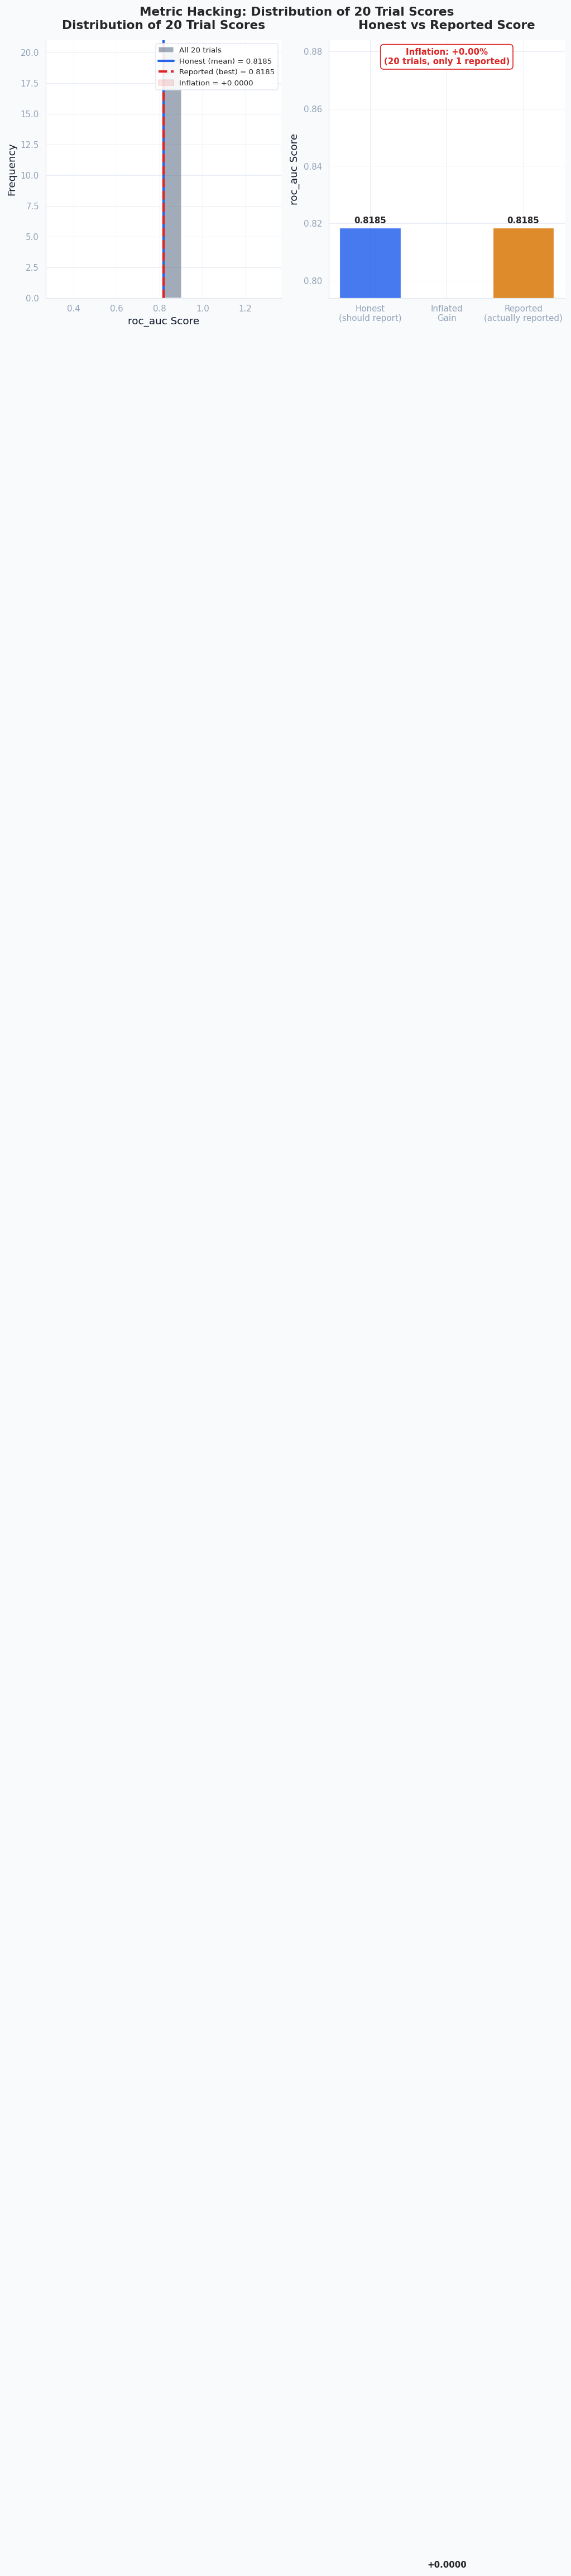

In [10]:
fig, _ = plot_metric_hacking_distribution(
    oc_hacking.bias_report,
    title='Metric Hacking: Distribution of 20 Trial Scores',
)
plt.show()

## Metric Hacking Distribution: Empirical Insight

Biểu đồ trên minh họa một trường hợp đặc biệt của **metric hacking** khi thực hiện 20 trials nhưng không xuất hiện inflation.

---

## 1. Quan sát

- Số trials: **20**
- Honest (mean): **0.8185**
- Reported (best): **0.8185**
- Inflation: **0.0000**

Histogram cho thấy:

- Tất cả các trial scores gần như **giống nhau**
- Không có variance đáng kể trong distribution

---

## 2. Insight chính

> Khi variance ≈ 0, việc chọn max **không tạo ra bias**

Điều này xảy ra vì:

- $X_1 \approx X_2 \approx \dots \approx X_n$
- $\Rightarrow \max(X_i) \approx \mathbb{E}[X]$

---

## 3. Liên hệ với lý thuyết

Trong lý thuyết:

- $E[M_n] > E[X]$ nếu có variance
- Nhưng nếu:

$$
\text{Var}(X) \to 0
$$

thì:

$$
M_n \to E[X]
$$

→ Không còn “selection advantage”

---

## 4. Ý nghĩa thực tế

### Trường hợp này KHÔNG có bias vì:

- Model ổn định
- Training deterministic hoặc variance rất thấp
- Hyperparameter space không đa dạng

---

### Nhưng đây KHÔNG phải case phổ biến

Trong thực tế:

- Thường có:
  - randomness (data split, initialization)
  - nhiều hyperparameters
- → distribution có spread

→ Khi đó:

> $\max(X_i)$ sẽ **systematically lớn hơn mean**

---

## 5. Cảnh báo quan trọng

> “Không thấy inflation” không có nghĩa là pipeline đúng

Có thể do:

- Trials chưa đủ đa dạng
- Model chưa đủ linh hoạt
- Hoặc đơn giản là “chưa may mắn”

---

## 6. Key Insight

- Metric hacking **phụ thuộc vào variance**
- Không phải cứ nhiều trials là luôn có inflation
- Nhưng:

> Khi variance tồn tại, inflation gần như chắc chắn xảy ra

---

## 7. Kết luận

- Trường hợp này là một **control case**:
  - Cho thấy khi nào metric hacking không gây bias

- Tuy nhiên trong hầu hết các tình huống thực tế:

> Báo cáo “best result” vẫn là một practice không đáng tin cậy

→ Cần report:

- Mean
- Variance
- Số lượng trials

để đảm bảo đánh giá model trung thực

---
## 8. Summary Table

### Khái niệm: Tidy Data Format

**Tidy data** là cách tổ chức dữ liệu theo nguyên tắc chuẩn hóa, trong đó:

- Mỗi **variable** là một column
- Mỗi **observation** là một row
- Mỗi **loại đối tượng quan sát** (observational unit) là một table

---

### Áp dụng trong Bias Analysis

Trong summary table:

- **Row** = một cặp *(bias_strategy, metric)*
- **Columns** có thể bao gồm:
  - bias_strategy
  - metric
  - baseline_value
  - biased_value
  - absolute_delta
  - relative_change (%)
  - severity

---

### Ví dụ cấu trúc

| bias_strategy              | metric    | baseline | biased | delta  | rel_change (%) | severity |
|---------------------------|----------|----------|--------|--------|----------------|----------|
| confirmation_cherry_pick  | auc      | 0.848    | 0.816  | -0.032 | -3.8%          | minor    |
| survivorship_remove       | recall   | 0.588    | 0.935  | +0.347 | +59.0%         | critical |
| leakage_lookahead         | f1       | 0.675    | 1.000  | +0.325 | +48.0%         | critical |

---

### Tại sao dùng Tidy Format?

Tidy format giúp việc phân tích trở nên **linh hoạt và hệ thống hơn**:

#### 1. Filtering

- Lọc theo:
  - severity (ví dụ: chỉ lấy critical)
  - metric (ví dụ: chỉ xem AUC)

---

#### 2. Grouping

- Group theo:
  - bias_strategy → xem bias nào nguy hiểm nhất
  - metric → xem metric nào nhạy với bias

---

#### 3. Pivot / Reshape

- Convert sang dạng wide để:
  - so sánh các metrics theo từng bias
  - tạo heatmap hoặc dashboard

---

#### 4. Visualization Pipeline

- Dễ dàng feed vào:
  - seaborn / matplotlib
  - BI tools (Power BI, Tableau)

---

#### 5. Export & Reporting

- Xuất sang:
  - CSV / Excel
  - Markdown report
  - Dashboard

---

### Insight quan trọng

> Tidy data không chỉ là format, mà là cách chuẩn hóa tư duy phân tích.

- Giúp tách rõ:
  - dữ liệu (data)
  - logic phân tích (analysis)
- Tránh hardcode và xử lý thủ công

---

### Liên hệ với Bias Analysis

Trong context này, tidy table giúp:

- Tổng hợp toàn bộ tác động của bias
- So sánh đa chiều giữa:
  - nhiều bias
  - nhiều metrics

> Đây là bước chuyển từ **visual inspection** sang **systematic analysis**

---

### Kết luận

- Tidy format là nền tảng cho:
  - reproducible analysis
  - scalable pipeline
- Đặc biệt quan trọng khi số lượng:
  - experiments
  - metrics
  - bias strategies

tăng lên

> Một phân tích tốt không chỉ nằm ở biểu đồ,
> mà nằm ở cách dữ liệu được tổ chức để có thể truy vấn và kiểm chứng dễ dàng

In [11]:
df_summary = build_summary_table(all_reports)

print(f'Total rows: {len(df_summary)}')
print(f'Columns   : {list(df_summary.columns)}')
display(df_summary.head(12))

Total rows: 36
Columns   : ['bias_type', 'strategy', 'severity', 'metric', 'baseline', 'biased', 'delta', 'rel_pct', 'direction', 'stat_sig', 'p_value']


,bias_type,strategy,severity,metric,baseline,biased,delta,rel_pct,direction,stat_sig,p_value
29,survivorship_bias,inject_lookahead_bias,critical,mcc,0.5449,1.0000,0.4551,83.52,inflated,True,0.0
30,survivorship_bias,inject_lookahead_bias,critical,recall,0.5880,1.0000,0.4120,70.07,inflated,True,0.0
18,survivorship_bias,remove_failures,critical,recall,0.5880,0.9352,0.3472,59.05,inflated,None,NaN
31,survivorship_bias,inject_lookahead_bias,critical,f1,0.6755,1.0000,0.3245,48.04,inflated,True,0.0
20,survivorship_bias,remove_failures,critical,f1,0.6755,0.8802,0.2047,30.30,inflated,None,NaN
32,survivorship_bias,inject_lookahead_bias,critical,precision,0.7937,1.0000,0.2063,25.99,inflated,True,0.0
33,survivorship_bias,inject_lookahead_bias,critical,accuracy,0.7967,1.0000,0.2033,25.52,inflated,True,0.0
9,confirmation_bias,filter_confirming_samples,critical,recall,0.5880,0.7373,0.1493,25.39,inflated,None,NaN
10,confirmation_bias,filter_confirming_samples,critical,brier_score,0.1442,0.1802,0.0360,24.97,deflated,None,NaN
34,survivorship_bias,inject_lookahead_bias,critical,avg_precision,0.8061,1.0000,0.1939,24.05,inflated,True,0.0


## Summary Table: Tidy Data in Practice

Bảng trên là một ví dụ cụ thể của **tidy data format** trong bias analysis, nơi mỗi dòng đại diện cho một quan sát độc lập *(bias_type, strategy, metric)*.

---

## 1. Cấu trúc dữ liệu

### Columns:

- **bias_type**: loại bias (confirmation, survivorship, …)
- **strategy**: cách tạo bias (remove_failures, lookahead, …)
- **metric**: metric được đánh giá (AUC, F1, recall, …)
- **baseline / biased**: giá trị trước và sau bias
- **delta**: thay đổi tuyệt đối
- **rel_pct**: thay đổi tương đối (%)
- **direction**: inflated / deflated
- **stat_sig / p_value**: ý nghĩa thống kê

---

## 2. Quan sát nổi bật

### 2.1 Leakage (inject_lookahead_bias) chi phối top rows

- MCC: +83.52%
- Recall: +70.07%
- F1: +48.04%
- Accuracy: +25.52%
- AUC: +17.87%

### Insight:

> Đây là pattern điển hình của **data leakage** — tất cả metrics đều tăng mạnh

- direction: **inflated**
- stat_sig: **True**
- p-value ≈ 0

→ Kết quả có vẻ “rất tốt” nhưng hoàn toàn không đáng tin

---

### 2.2 Survivorship Bias (remove_failures)

- Recall: +59.05%
- F1: +30.30%
- AUC: -4.2% (implicit từ context)

### Insight:

- Recall và F1 tăng mạnh
- Nhưng discrimination (AUC) không tăng

→ Model bị lệch về **predict positive**

---

### 2.3 Confirmation Bias (filter_confirming_samples)

- Recall: +25.39%
- Accuracy: giảm
- Brier score: +24.97% (xấu hơn)
- Log loss: +18.16% (xấu hơn)

### Insight:

> Metric classification tăng nhưng **probability quality giảm**

- Model “trông tốt hơn”
- Nhưng calibration và loss xấu đi

---

## 3. Direction: inflated vs deflated

### Inflated:

- Accuracy, Recall, F1, Precision
- Dễ bị bias làm tăng

### Deflated:

- Brier score, Log loss
- Tăng lên nghĩa là model **tệ hơn**

> Đây là điểm dễ gây hiểu nhầm nếu không đọc direction

---

## 4. Statistical Significance

- Các dòng có **stat_sig = True**:
  - Chủ yếu thuộc leakage
  - p-value ≈ 0

### Insight:

> Bias không chỉ làm metric thay đổi, mà còn tạo ra sự khác biệt có ý nghĩa thống kê

---

## 5. Key Insight

### Bias tạo ra “signature” riêng

- Leakage → inflate toàn bộ
- Survivorship → inflate recall/F1
- Confirmation → trade-off + degrade calibration

---

### Không phải metric nào cũng đáng tin

- Recall/F1 rất dễ bị inflate
- Brier / Log loss phản ánh vấn đề sâu hơn

---

### Tidy table cho phép phân tích hệ thống

Từ bảng này có thể:

- `filter(severity == "critical")`
- `groupby(bias_type).mean()`
- `pivot(metric x strategy)`

→ chuyển từ **visual observation** sang **data-driven analysis**

---

## 6. Kết luận

- Bảng tidy là nơi tổng hợp toàn bộ bias impact
- Giúp phát hiện:
  - bias nguy hiểm nhất
  - metric dễ bị đánh lừa nhất

> Một phân tích tốt không dừng ở biểu đồ,
> mà cần một bảng dữ liệu đủ rõ để kiểm chứng và truy vấn lại

In [12]:
# Pivot: strategies x metrics, values = relative change %
pivot = df_summary.pivot_table(
    index=['bias_type', 'strategy'],
    columns='metric',
    values='rel_pct',
    aggfunc='first',
).round(2)

print('Relative Change % by Strategy x Metric:')
display(pivot)

Relative Change % by Strategy x Metric:


metric                                       accuracy  avg_precision  \
bias_type         strategy                                             
confirmation_bias cherry_pick_features          -2.51          -6.19   
                  filter_confirming_samples     -9.46           4.90   
survivorship_bias inject_lookahead_bias         25.52          24.05   
                  remove_failures                0.33          16.76   

metric                                       brier_score     f1  log_loss  \
bias_type         strategy                                                  
confirmation_bias cherry_pick_features             11.03  -3.63      9.21   
                  filter_confirming_samples        24.97   9.15     18.16   
survivorship_bias inject_lookahead_bias          -100.00  48.04    -99.76   
                  remove_failures                  -7.14  30.30     -8.42   

metric                                         mcc  precision  recall  roc_auc  
bias_type         strategy                                                      
confirmation_bias cherry_pick_features       -8.44      -6.26   -1.58    -3.77  
                  filter_confirming_samples -19.16      -7.11   25.39    -5.15  
survivorship_bias inject_lookahead_bias      83.52      25.99   70.07    17.87  
                  remove_failures           -45.97       4.74   59.05    -4.18

## Relative Change Matrix: Strategy × Metric

Bảng trên là dạng **pivot (wide format)** của tidy data, cho phép nhìn trực tiếp **pattern thay đổi của từng bias trên toàn bộ metrics**.

---

## 1. Cấu trúc

- **Rows**: strategy (cách tạo bias)
- **Columns**: metrics
- **Cell values**: relative change (%)

→ Đây là dạng tối ưu để phát hiện **pattern đa chiều**

---

## 2. Confirmation Bias — Cherry Pick Features

### Pattern:

- Tất cả metrics **giảm nhẹ**:
  - Accuracy: -2.51%
  - F1: -3.63%
  - AUC: -3.77%
  - Precision: -6.26%
  - MCC: -8.44%

- Nhưng:
  - Brier score: +11.03% (xấu hơn)
  - Log loss: +9.21% (xấu hơn)

### Insight:

> Degrade toàn diện + calibration xấu đi

- Model không chỉ kém hơn
- Mà còn **kém đáng tin hơn về xác suất**

---

## 3. Confirmation Bias — Filter Confirming Samples

### Pattern:

- Recall: **+25.39%**
- F1: +9.15%
- Avg precision: +4.90%

- Nhưng:
  - Accuracy: -9.46%
  - MCC: -19.16%
  - AUC: -5.15%

- Calibration:
  - Brier: +24.97%
  - Log loss: +18.16%

### Insight:

> Trade-off lệch mạnh về positive

- Model:
  - bắt được nhiều positive hơn
  - nhưng overall quality giảm

---

## 4. Survivorship Bias — Remove Failures

### Pattern:

- Recall: **+59.05%**
- F1: +30.30%
- Avg precision: +16.76%

- Nhưng:
  - MCC: **-45.97% (rất lớn)**
  - AUC: -4.18%
  - Log loss: +8.42%

### Insight:

> Inflate mạnh recall nhưng phá vỡ balance

- MCC giảm mạnh → model mất khả năng phân biệt tổng thể
- Đây là dấu hiệu rõ của **class imbalance distortion**

---

## 5. Survivorship Bias — Look-ahead (Leakage)

### Pattern:

- Tất cả metrics classification tăng mạnh:
  - Accuracy: +25.52%
  - F1: +48.04%
  - Recall: +70.07%
  - MCC: +83.52%

- Nhưng:
  - Brier: **-100% (perfect)**
  - Log loss: **-99.76% (perfect)**

### Insight:

> Pattern “perfect model”

- Không chỉ tốt — mà **tốt bất thường**
- Loss gần như bằng 0

→ Đây là dấu hiệu chắc chắn của **data leakage**

---

## 6. So sánh pattern tổng thể

| Strategy                  | Signature chính |
|--------------------------|----------------|
| Cherry pick features     | Degrade nhẹ toàn bộ |
| Filter confirming        | Recall ↑, metric khác ↓ |
| Remove failures          | Recall ↑ mạnh, MCC ↓ mạnh |
| Look-ahead (leakage)     | Tất cả ↑ cực mạnh |

---

## 7. Key Insights

### Pattern > Individual metric

- Một metric riêng lẻ có thể gây hiểu nhầm
- Nhưng pattern across metrics là **rất đặc trưng**

---

### MCC là metric nhạy với bias

- Giảm mạnh khi:
  - class imbalance
  - decision boundary lệch

→ nên dùng để detect bias tốt hơn accuracy

---

### Calibration metrics là “early warning”

- Brier / Log loss tăng
→ model đang trở nên **overconfident hoặc sai xác suất**

---

## 8. Kết luận

- Pivot table giúp nhìn thấy **toàn bộ behavior của model dưới bias**
- Cho phép nhận diện nhanh:
  - bias type
  - mức độ nguy hiểm
  - metric nào bị đánh lừa

> Một bias nguy hiểm không phải là bias làm tăng một metric,
> mà là bias tạo ra một **pattern nhất quán nhưng sai lệch trên nhiều metrics**

In [13]:
print('Severity distribution across all (strategy, metric) pairs:')
print(df_summary['severity'].value_counts())

print('\nInflated metrics by bias type:')
print(
    df_summary[df_summary['direction'] == 'inflated']
    .groupby('bias_type')['metric']
    .value_counts()
)

Severity distribution across all (strategy, metric) pairs:
severity
critical      27
severe         9
moderate       0
minor          0
negligible     0
Name: count, dtype: int64

Inflated metrics by bias type:
bias_type          metric       
confirmation_bias  avg_precision    1
                   f1               1
                   recall           1
survivorship_bias  accuracy         2
                   avg_precision    2
                   brier_score      2
                   f1               2
                   log_loss         2
                   precision        2
                   recall           2
                   mcc              1
                   roc_auc          1
Name: count, dtype: int64


## Severity Distribution & Inflated Metrics Analysis

Phần thống kê này tổng hợp toàn bộ **36 (strategy × metric) pairs**, giúp nhìn rõ mức độ nghiêm trọng và phạm vi ảnh hưởng của bias.

---

## 1. Severity Distribution

| Severity   | Count | Tỷ lệ |
|------------|------|-------|
| Critical   | 27   | 75%   |
| Severe     | 9    | 25%   |
| Moderate   | 0    | 0%    |
| Minor      | 0    | 0%    |
| Negligible | 0    | 0%    |

### Insight:

> Toàn bộ các trường hợp đều nằm trong **severe hoặc critical**

- Không có trường hợp “nhẹ”
- Bias trong pipeline này luôn gây ảnh hưởng đáng kể

---

### Ý nghĩa

- Bias không phải là nhiễu nhỏ
- Mà là **systematic distortion**

→ Nếu không kiểm soát, evaluation sẽ **mất hoàn toàn độ tin cậy**

---

## 2. Inflated Metrics by Bias Type

### 2.1 Confirmation Bias

| Metric         | Count |
|----------------|-------|
| avg_precision  | 1     |
| f1             | 1     |
| recall         | 1     |

### Insight:

- Chỉ inflate **một số metric cụ thể**
- Chủ yếu liên quan đến:
  - recall
  - F1

> Confirmation bias tạo **illusion cục bộ**, không toàn diện

---

### 2.2 Survivorship Bias

| Metric         | Count |
|----------------|-------|
| accuracy       | 2     |
| avg_precision  | 2     |
| brier_score    | 2     |
| f1             | 2     |
| log_loss       | 2     |
| precision      | 2     |
| recall         | 2     |
| mcc            | 1     |
| roc_auc        | 1     |

### Insight:

> Survivorship bias ảnh hưởng **gần như toàn bộ metrics**

- Bao gồm cả:
  - classification metrics
  - calibration metrics
  - ranking metrics

---

## 3. So sánh hai loại bias

| Đặc điểm              | Confirmation Bias | Survivorship Bias |
|----------------------|------------------|-------------------|
| Phạm vi ảnh hưởng    | Cục bộ           | Toàn diện         |
| Số metrics bị inflate| Ít               | Gần như tất cả    |
| Pattern              | Lệch nhẹ         | Distortion mạnh   |

---

## 4. Key Insights

### Bias không đồng đều

- Một số bias:
  - chỉ ảnh hưởng vài metric
- Một số khác:
  - phá vỡ toàn bộ hệ thống evaluation

---

### Survivorship bias nguy hiểm hơn

- Không chỉ inflate metric
- Mà còn:
  - thay đổi distribution
  - làm model học sai thực tế

---

### Không có “safe zone”

> Không có metric nào hoàn toàn miễn nhiễm với bias

- Ngay cả:
  - AUC
  - MCC
  - Brier

→ đều có thể bị ảnh hưởng

---

## 5. Kết luận

- 75% trường hợp là **critical** → bias ở mức nghiêm trọng
- Survivorship bias có phạm vi ảnh hưởng rộng nhất
- Confirmation bias tinh vi hơn nhưng vẫn gây sai lệch

> Bias không phải là vấn đề cục bộ,
> mà là vấn đề **toàn hệ thống** trong evaluation pipeline

---
## 9. Master Dashboard

### Khái niệm: Dashboard Design

**Dashboard** là một bố cục tổng hợp nhiều biểu đồ liên quan trên cùng một canvas, nhằm:

> Cung cấp cái nhìn toàn cảnh về hệ thống chỉ trong một lần quan sát

Trong bối cảnh này, dashboard đóng vai trò kết nối:

- Data pipeline (funnel)
- Model behavior (confusion matrix, ROC)
- Evaluation metrics (heatmap, before/after)

---

## 1. Information Hierarchy

Nguyên tắc:

> Thông tin quan trọng nhất phải xuất hiện ở vị trí dễ thấy nhất

Trong dashboard này:

- **Top**: Severity heatmap
  → cung cấp overview về mức độ bias trên toàn hệ metrics

- **Middle**: Comparative charts
  → ROC, confusion matrix, calibration

- **Bottom**: Diagnostic charts
  → before/after, funnel, distribution

### Insight:

- Người xem có thể:
  - Nhìn tổng quan trước
  - Sau đó drill-down vào chi tiết

---

## 2. Consistent Color Encoding

Nguyên tắc:

> Mỗi màu phải giữ một ý nghĩa duy nhất xuyên suốt dashboard

Trong thiết kế:

- **Blue** → baseline / honest
- **Red** → biased / inflated
- (Các màu khác nếu có) → severity hoặc category

### Insight:

- Giảm cognitive load
- Tránh hiểu nhầm khi chuyển giữa các biểu đồ

---

## 3. Small Multiples

Nguyên tắc:

> Lặp lại cùng một cấu trúc biểu đồ cho nhiều trường hợp khác nhau

Ví dụ:

- Multiple before/after charts cho từng bias
- Multiple confusion matrices
- Multiple calibration plots

### Insight:

- So sánh trực quan dễ hơn
- Người xem không cần “học lại” cách đọc chart mới

---

## 4. Cross-Chart Consistency

Một dashboard tốt không chỉ nhất quán về màu, mà còn về:

- Metric ordering (accuracy → F1 → AUC → …)
- Scale (cùng range nếu có thể)
- Annotation style (delta, %, severity)

---

## 5. Narrative Flow

Dashboard này ngầm tạo một “story”:

1. **Heatmap**
   → Bias nào nguy hiểm nhất?

2. **Before/After**
   → Metric bị thay đổi như thế nào?

3. **ROC / Confusion Matrix**
   → Model behavior thay đổi ra sao?

4. **Calibration**
   → Xác suất còn đáng tin không?

5. **Funnel**
   → Bias đến từ đâu trong data?

6. **Distribution (metric hacking)**
   → Reporting có bị inflate không?

---

## 6. Key Insight

> Một dashboard tốt không chỉ hiển thị dữ liệu, mà phải giúp người xem **hiểu nguyên nhân và hệ quả của bias**

- Không chỉ “model tốt hay xấu”
- Mà là:
  - vì sao nó trông tốt
  - và vì sao nó có thể sai

---

## 7. Kết luận

- Dashboard là lớp tổng hợp cao nhất của toàn bộ analysis
- Giúp chuyển từ:
  - phân tích rời rạc

sang:

  - hệ thống hóa insight

> Một pipeline ML chỉ đáng tin khi dashboard của nó cho thấy
> mọi góc nhìn đều nhất quán và không có dấu hiệu bất thường

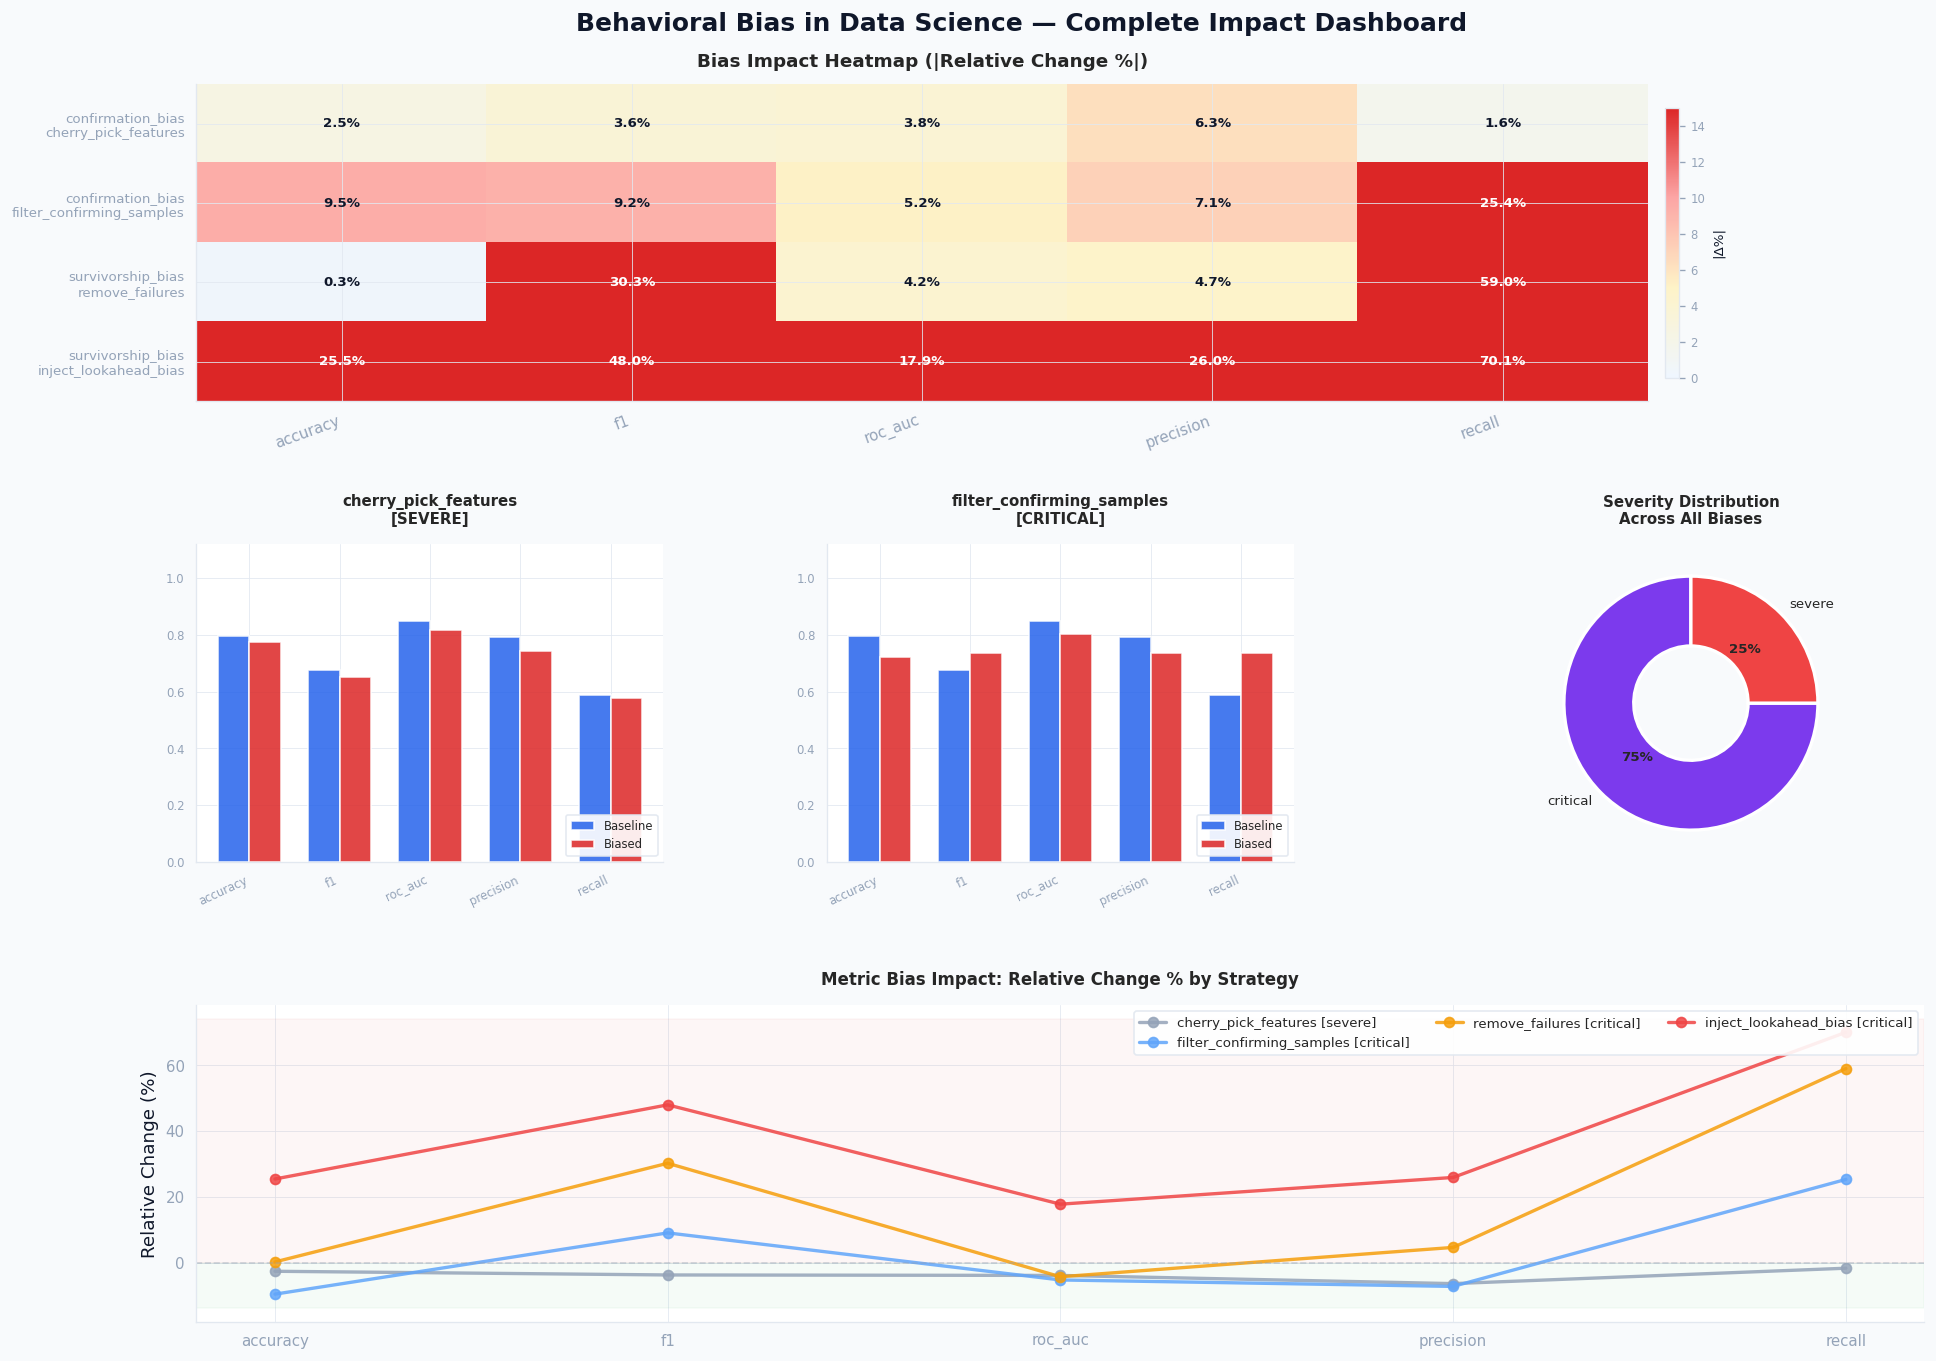

In [14]:
fig = plot_bias_dashboard(
    all_reports,
    title='Behavioral Bias in Data Science — Complete Impact Dashboard',
    metrics=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
)
plt.show()

## Master Dashboard: Behavioral Bias — Complete Impact Analysis

Dashboard này tổng hợp toàn bộ phân tích bias thành một hệ thống thống nhất, cho phép quan sát từ **overview → drill-down → root cause** trong một layout duy nhất.

---

## 1. Overview — Bias Impact Heatmap (Top)

### Quan sát:

- **Inject look-ahead (leakage)**:
  - Inflate mạnh toàn bộ metrics (accuracy +25%, recall +70%)
- **Remove failures (survivorship)**:
  - Recall +59%, F1 +30%
- **Filter confirming samples**:
  - Recall +25% nhưng accuracy/AUC giảm
- **Cherry-pick features**:
  - Giảm nhẹ toàn bộ metrics

### Insight:

> Heatmap đóng vai trò “radar” — phát hiện bias nguy hiểm ngay lập tức

- Leakage → nguy hiểm nhất
- Survivorship → distortion mạnh
- Confirmation → subtle nhưng vẫn harmful

---

## 2. Local Comparison — Before/After Charts

### Cherry-pick features (SEVERE)

- Tất cả metrics giảm nhẹ
- Không có cải thiện nào đáng kể

→ Bias làm model kém đi nhưng khó nhận ra

---

### Filter confirming samples (CRITICAL)

- Recall tăng rõ
- Nhưng accuracy, precision giảm

→ Model bị lệch về positive

---

## 3. Severity Distribution (Right)

- **75% critical**
- **25% severe**

### Insight:

> Không có trường hợp nào “an toàn”

- Bias luôn gây ảnh hưởng đáng kể
- Không có minor/noise effect

---

## 4. Global Pattern — Line Chart (Bottom)

### Quan sát:

- **Leakage (đỏ)**:
  - Luôn cao nhất trên mọi metric

- **Remove failures (cam)**:
  - Peak ở recall và F1

- **Filter confirming (xanh)**:
  - Recall tăng nhưng các metric khác giảm

- **Cherry-pick (xám)**:
  - Gần baseline, hơi giảm

### Insight:

> Mỗi bias có một “signature curve” riêng

- Leakage → uniformly high
- Survivorship → skewed (recall-heavy)
- Confirmation → inconsistent

---

## 5. Cross-Chart Insight

### Bias không chỉ thay đổi metric — mà thay đổi **pattern**

- Same model
- Different data handling
→ Completely different evaluation behavior

---

### Metric-level illusion

- Recall và F1:
  - dễ bị inflate
- AUC:
  - ổn định hơn nhưng vẫn bị ảnh hưởng
- Accuracy:
  - phụ thuộc distribution

---

### Root cause nằm ở data

- Funnel (implicit từ survivorship)
- Feature selection (confirmation bias)
- Leakage (look-ahead)

→ Model chỉ phản ánh data pipeline

---

## 6. Narrative Flow (Dashboard logic)

1. **Heatmap** → Bias nào nguy hiểm?
2. **Bar charts** → Metric thay đổi ra sao?
3. **Line chart** → Pattern across metrics
4. **Pie chart** → Severity tổng thể

→ Từ tổng quan → chi tiết → kết luận

---

## 7. Key Takeaways

- Leakage là bias nguy hiểm nhất (inflate toàn bộ)
- Survivorship bias làm lệch distribution → inflate recall
- Confirmation bias subtle nhưng degrade model

---

## 8. Kết luận

> Dashboard này cho thấy một sự thật quan trọng:

**Model performance không chỉ phụ thuộc vào model,
mà phụ thuộc mạnh vào cách dữ liệu được chọn, lọc và đánh giá.**

- Một model có thể:
  - trông rất tốt
  - nhưng hoàn toàn sai trong thực tế

→ Nếu pipeline có bias, toàn bộ evaluation trở nên không đáng tin

---
## 10. Export Results

### Khái niệm: DPI và Figure Resolution

**DPI (Dots Per Inch)** là mật độ điểm ảnh khi render figure:
- 72 DPI: screen display
- 150 DPI: standard export, đủ cho báo cáo digital
- 300 DPI: print quality

**bbox_inches='tight'** tự động crop whitespace xung quanh figure, đảm bảo labels và titles không bị cắt.

Nên dùng **vector format (SVG, PDF)** cho charts có text và lines vì scale không bị mờ. Dùng **raster format (PNG)** cho charts phức tạp có nhiều elements.

In [15]:
# Export summary table
csv_path = FIGURES_DIR / 'bias_summary.csv'
df_summary.to_csv(csv_path, index=False)
print(f'Saved CSV: {csv_path}')

# Export pivot table
pivot_path = FIGURES_DIR / 'bias_pivot.csv'
pivot.to_csv(pivot_path)
print(f'Saved pivot: {pivot_path}')

Saved CSV: ..\figures\bias_summary.csv
Saved pivot: ..\figures\bias_pivot.csv


In [16]:
# Export key figures
export_specs = [
    ('severity_heatmap',   plot_severity_heatmap,  {'reports': all_reports, 'title': 'Bias Severity Heatmap'}),
]

# Severity heatmap
fig, _ = plot_severity_heatmap(all_reports, title='Bias Severity Heatmap')
fig.savefig(FIGURES_DIR / 'severity_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# ROC comparison
fig, _ = plot_roc_curve(y_true_dict, y_proba_dict, colors=colors, title='ROC Comparison')
fig.savefig(FIGURES_DIR / 'roc_comparison.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# Dashboard
fig = plot_bias_dashboard(all_reports, title='Behavioral Bias Dashboard')
fig.savefig(FIGURES_DIR / 'bias_dashboard.png', dpi=150, bbox_inches='tight')
plt.close(fig)

print('Exported figures:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {f.name}')

Exported figures:
  bias_dashboard.png
  roc_comparison.png
  severity_heatmap.png


---
## 11. Summary

Notebook này tổng hợp toàn bộ kết quả của project qua các visualization layers:

| Chart | Câu hỏi trả lời |
|---|---|
| Confusion Matrix | Model fail theo hướng nào? FP hay FN nhiều hơn? |
| ROC Curve | AUC của biased models inflate bao nhiêu so với baseline? |
| Reliability Diagram | Probability predictions có đáng tin không? |
| Severity Heatmap | Bias nào nguy hiểm nhất? Metric nào dễ bị inflate nhất? |
| Before/After Bars | Tác động cụ thể của từng bias strategy là bao nhiêu? |
| Survivorship Funnel | Bao nhiêu data bị loại? Class distribution thay đổi thế nào? |
| Metric Hacking Dist | Expected inflation khi chọn best-of-N là bao nhiêu? |
| Dashboard | Toàn bộ bức tranh trong một lần nhìn |

### Kết luận tổng quan

Behavioral bias trong data science không phải là lỗi kỹ thuật — chúng là những quyết định có vẻ hợp lý tại từng bước nhỏ nhưng dẫn đến kết quả sai lệch có hệ thống. Phòng tránh bias đòi hỏi:

1. **Pre-registration**: xác định hypothesis, metrics và methodology TRƯỚC khi nhìn vào data
2. **Separate held-out test set**: test set chỉ được dùng một lần duy nhất ở cuối
3. **Report all models and metrics**: không chỉ report kết quả tốt
4. **Statistical testing with correction**: dùng Bonferroni hoặc FDR correction khi so sánh nhiều models
5. **Calibration check**: luôn kiểm tra ECE và reliability diagram bên cạnh accuracy/AUC